# Notebook 06 — Эксперимент 4: Межрыночные связи

## Исследовательский вопрос
**«Насколько акция самостоятельна — или она просто ходит вместе с рынком?»**

## Метрики (после чистки корреляций)
| Метрика | Обоснование | Что убрано |
|---|---|---|
| corr_sp500 | Базовая мера связи с рынком | r_squared (ρ=1.0 с corr_sp500) |
| corr_calm | Корреляция при низкой волатильности | corr_stress (ρ=0.971 с corr_sp500) |
| tail_dependence | P(акция падает \| рынок падает) | — |

## Ключевые концепции
- **Correlation breakdown:** в кризис корреляции растут — диверсификация «ломается»
- **Tail dependence:** акция может иметь умеренную corr_sp500 но высокую зависимость именно в кризис
- **corr_calm:** «мирная» корреляция — насколько акция следует рынку в спокойный период

## Почему эти три метрики
corr_sp500 — среднее, corr_calm — поведение в норме,
tail_dependence — поведение в стрессе.
Вместе они дают полный профиль связи акции с рынком.

## 1. Импорты и загрузка

In [1]:
import warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.optimize import linear_sum_assignment
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    calinski_harabasz_score, davies_bouldin_score,
    adjusted_rand_score
)

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 150, 'axes.spines.top': False,
    'axes.spines.right': False, 'figure.facecolor': 'white',
    'font.size': 10,
})

df       = pd.read_parquet('data/features.parquet')
meta     = pd.read_csv('data/sp500_meta.csv', index_col='ticker')
df       = df.join(meta[['sector', 'name']], how='left')
res_exp1 = pd.read_parquet('data/results_exp1.parquet')
res_exp2 = pd.read_parquet('data/results_exp2.parquet')
res_exp3 = pd.read_parquet('data/results_exp3.parquet')

with open('data/feature_groups.json') as f:
    FEATURE_GROUPS = json.load(f)

FEATURES = FEATURE_GROUPS['market']
LABELS   = {
    'corr_sp500'     : 'Корр. S&P 500',
    'corr_calm'      : 'Корр. (спокойный)',
    'tail_dependence': 'Tail Dependence',
}
EXP_NAME    = 'Эксперимент 4: Межрыночные связи'
SAVE_PREFIX = 'plots/06_exp4'

X_raw = df[FEATURES].dropna().copy()
print(f"Акций: {len(X_raw)} | Метрики: {FEATURES}")
X_raw.describe().round(3)

Акций: 481 | Метрики: ['corr_sp500', 'corr_calm', 'tail_dependence']


,corr_sp500,corr_calm,tail_dependence
count,481.000,481.000,481.000
mean,0.589,0.388,0.413
std,0.110,0.128,0.095
min,0.176,0.047,0.137
25%,0.530,0.304,0.342
50%,0.599,0.399,0.411
75%,0.666,0.479,0.479
max,0.822,0.692,0.671


## 2. Анализ распределений и correlation breakdown

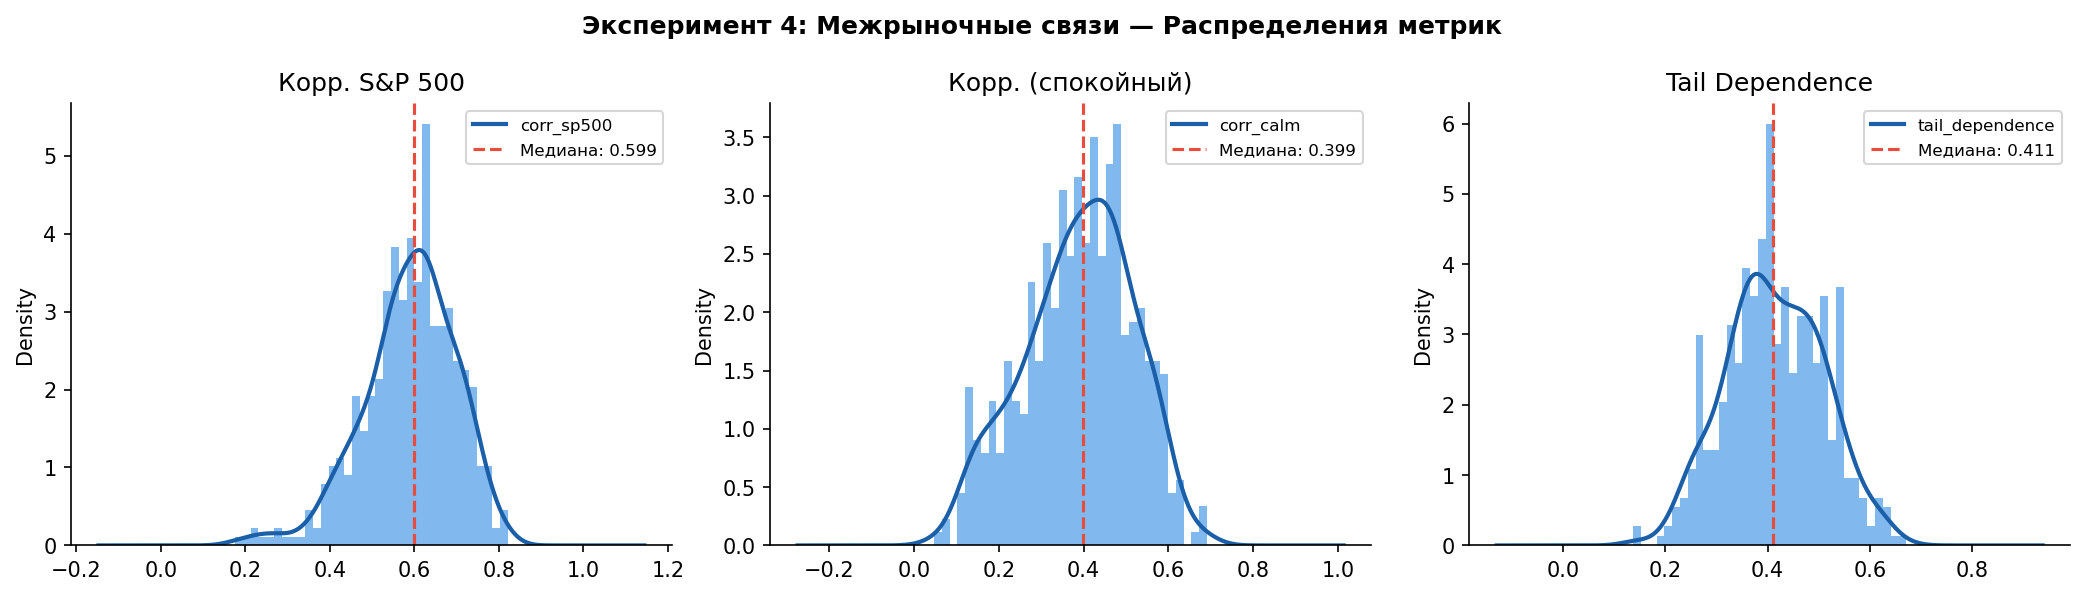

Correlation breakdown (corr_stress - corr_calm):
  Среднее: +0.265
  100% акций коррелируют сильнее в стресс
  Максимальный рост корреляции: +0.553


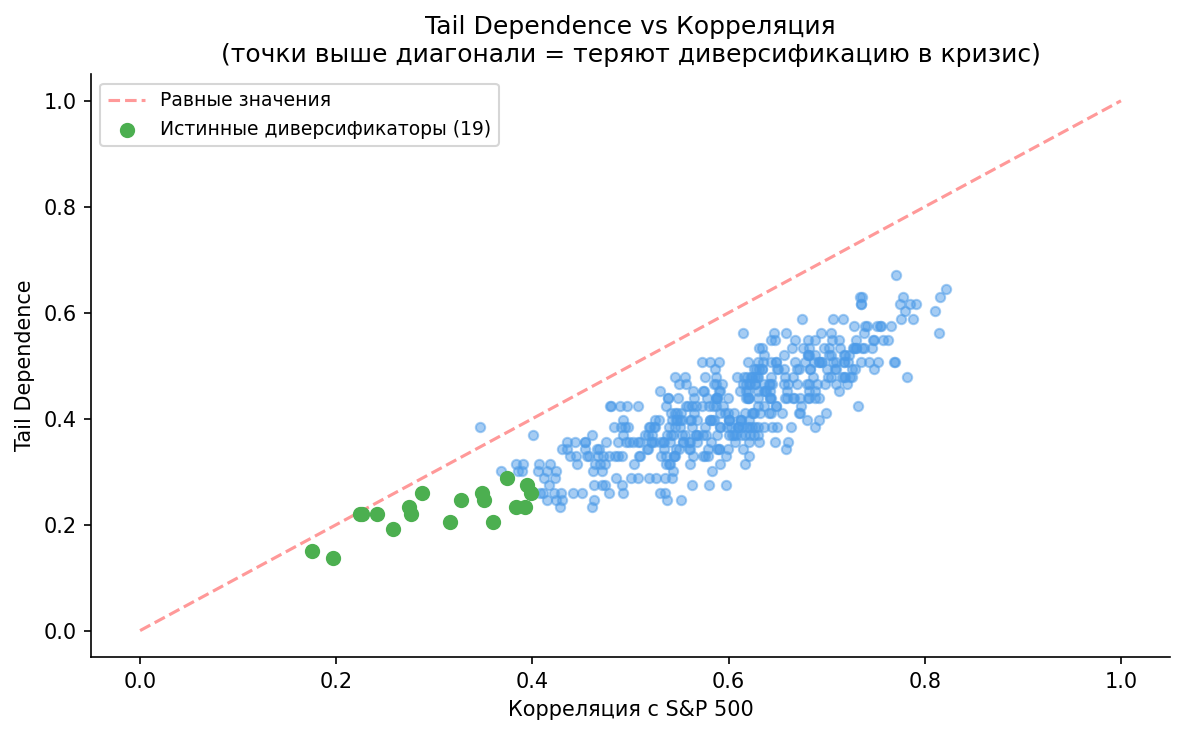


Акции с низкой корр. И низкой tail dep. (истинные диверсификаторы): 19
        corr_sp500  corr_calm  tail_dependence                  sector
ticker                                                                
CPB          0.226      0.076            0.219        Consumer Staples
CAG          0.274      0.148            0.233        Consumer Staples
CHD          0.360      0.135            0.205        Consumer Staples
CLX          0.225      0.124            0.219        Consumer Staples
CTRA         0.383      0.252            0.233                  Energy
DG           0.327      0.162            0.247        Consumer Staples
DPZ          0.349      0.192            0.260  Consumer Discretionary
EQT          0.316      0.201            0.205                  Energy
FSLR         0.394      0.283            0.274  Information Technology
GIS          0.277      0.075            0.219        Consumer Staples
HRL          0.287      0.123            0.260        Consumer Staples
KR   

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle(f'{EXP_NAME} — Распределения метрик',
             fontsize=12, fontweight='bold')

for ax, feat in zip(axes, FEATURES):
    data = X_raw[feat].dropna()
    ax.hist(data, bins=35, color='#4C9BE8', alpha=0.7, density=True)
    data.plot.kde(ax=ax, color='#1a5fa8', linewidth=2)
    ax.axvline(data.median(), color='#e74c3c', linestyle='--',
               linewidth=1.5,
               label=f'Медиана: {data.median():.3f}')
    ax.set_title(LABELS[feat])
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_distributions.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Correlation breakdown
if 'corr_stress' in df.columns:
    breakdown = df['corr_stress'] - df['corr_calm']
    print(f"Correlation breakdown (corr_stress - corr_calm):")
    print(f"  Среднее: {breakdown.mean():+.3f}")
    print(f"  {(breakdown > 0).mean()*100:.0f}% акций коррелируют "
          f"сильнее в стресс")
    print(f"  Максимальный рост корреляции: {breakdown.max():+.3f}")

# Tail dependence vs corr_sp500
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_raw['corr_sp500'], X_raw['tail_dependence'],
           alpha=0.5, s=20, color='#4C9BE8')
ax.set_xlabel('Корреляция с S&P 500')
ax.set_ylabel('Tail Dependence')
ax.set_title('Tail Dependence vs Корреляция\n'
             '(точки выше диагонали = теряют диверсификацию в кризис)')

lim = np.linspace(0, 1, 100)
ax.plot(lim, lim, 'r--', alpha=0.4, label='Равные значения')
ax.legend(fontsize=9)

# Выделяем истинных диверсификаторов
true_div = X_raw[
    (X_raw['corr_sp500'] < 0.4) &
    (X_raw['tail_dependence'] < 0.3)
]
if len(true_div) > 0:
    ax.scatter(true_div['corr_sp500'], true_div['tail_dependence'],
               color='#4CAF50', s=40, zorder=5,
               label=f'Истинные диверсификаторы ({len(true_div)})')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_tail_vs_corr.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nАкции с низкой корр. И низкой tail dep. "
      f"(истинные диверсификаторы): {len(true_div)}")
if len(true_div) > 0:
   show_div = true_div[FEATURES].copy()
show_div['sector'] = df.loc[true_div.index, 'sector']
print(show_div.round(3).to_string())

## 3. Масштабирование и выбор K

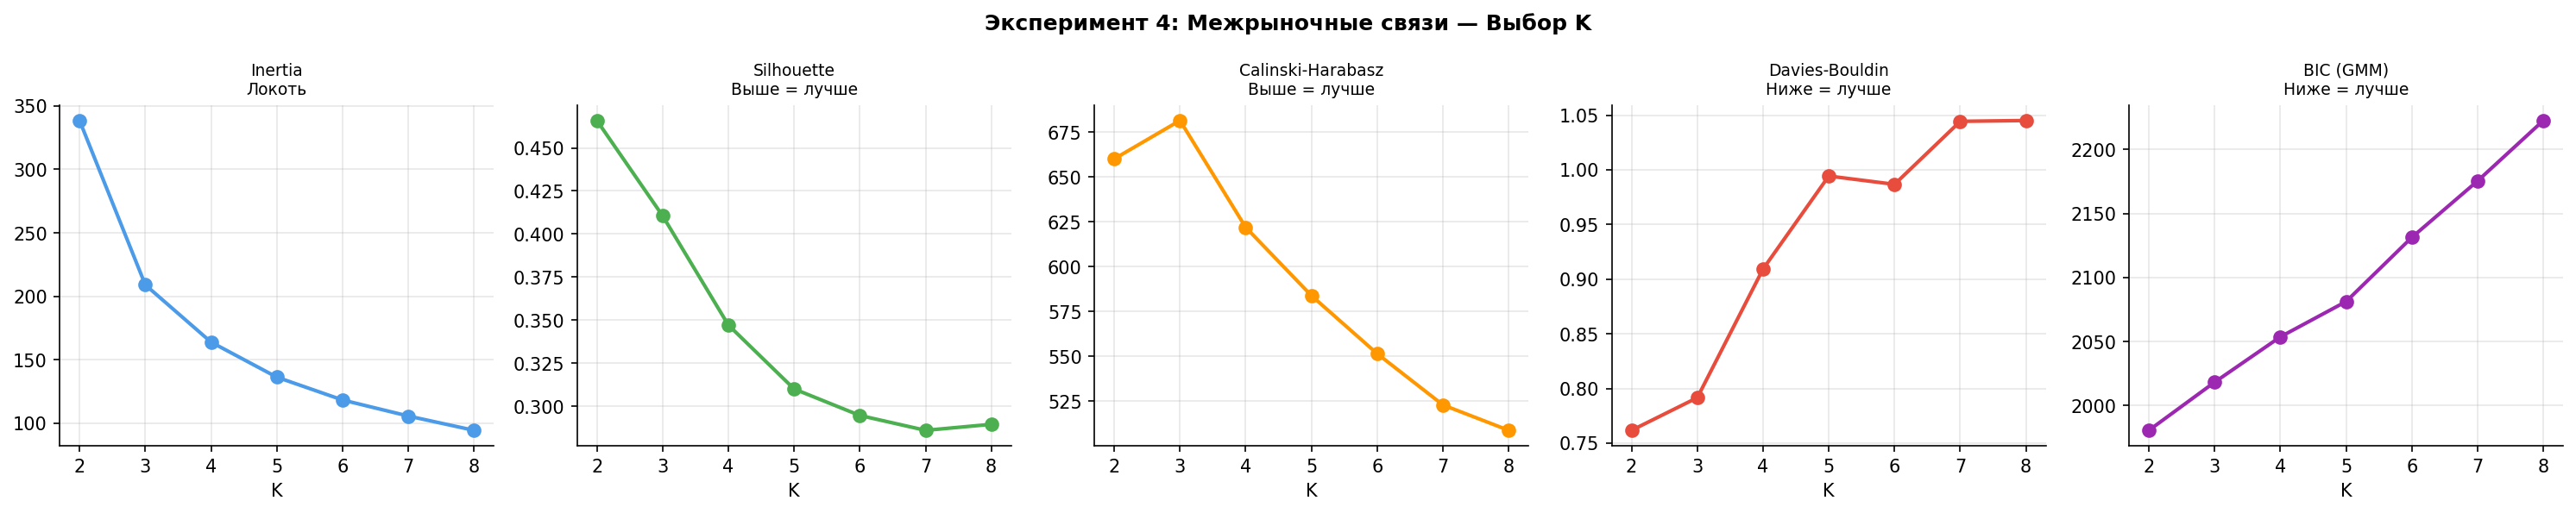

   Inertia  Silhouette     CH     DB  BIC(GMM)
K                                             
2    338.5       0.466  660.1  0.762    1980.7
3    209.0       0.411  681.5  0.792    2018.3
4    163.9       0.347  622.0  0.909    2053.7
5    136.3       0.310  583.9  0.994    2081.3
6    118.3       0.295  551.6  0.987    2131.3
7    105.6       0.286  523.0  1.044    2175.4
8     94.4       0.290  508.8  1.045    2222.6


In [3]:
scaler   = RobustScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_raw),
    index=X_raw.index, columns=FEATURES
)

K_RANGE = range(2, 9)
inertias, silhouettes, ch_scores, db_scores, bic_scores = [], [], [], [], []

for k in K_RANGE:
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, lbl))
    ch_scores.append(calinski_harabasz_score(X_scaled, lbl))
    db_scores.append(davies_bouldin_score(X_scaled, lbl))
    gmm_k = GaussianMixture(n_components=k, random_state=42, n_init=5)
    gmm_k.fit(X_scaled)
    bic_scores.append(gmm_k.bic(X_scaled))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle(f'{EXP_NAME} — Выбор K', fontsize=12, fontweight='bold')
for ax, (vals, title, sub, color) in zip(axes, [
    (inertias,    'Inertia',           'Локоть',         '#4C9BE8'),
    (silhouettes, 'Silhouette',        'Выше = лучше',   '#4CAF50'),
    (ch_scores,   'Calinski-Harabasz', 'Выше = лучше',   '#FF9800'),
    (db_scores,   'Davies-Bouldin',    'Ниже = лучше',   '#e74c3c'),
    (bic_scores,  'BIC (GMM)',         'Ниже = лучше',   '#9C27B0'),
]):
    ax.plot(list(K_RANGE), vals, 'o-', color=color, linewidth=2, markersize=7)
    ax.set_title(f'{title}\n{sub}', fontsize=9)
    ax.set_xlabel('K')
    ax.set_xticks(list(K_RANGE))
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

k_table = pd.DataFrame({
    'K': list(K_RANGE),
    'Inertia': [round(v,1) for v in inertias],
    'Silhouette': [round(v,3) for v in silhouettes],
    'CH': [round(v,1) for v in ch_scores],
    'DB': [round(v,3) for v in db_scores],
    'BIC(GMM)': [round(v,1) for v in bic_scores],
}).set_index('K')
print(k_table.to_string())

## 4. Дендрограмма

Эксперимент 4: Межрыночные связи — Агломеративная кластеризация (Ward)

Доступные признаки для вывода профилей: ['corr_sp500 ', 'corr_calm', 'tail_dependence']

Расстояния последних слияний (дендрограмма):
  K=8→7: dist=3.768, gap=1.161
  K=7→6: dist=4.930, gap=0.269
  K=6→5: dist=5.199, gap=1.097
  K=5→4: dist=6.296, gap=1.493
  K=4→3: dist=7.789, gap=0.749
  K=3→2: dist=8.538, gap=9.917
  K=2→1: dist=18.455, gap=10.517 ← МАКСИМУМ

→ Дендрограмма предлагает K=2

Метрики качества для K=2..8 (агломеративная кластеризация)

   K   Silhouette           CH           DB
---------------------------------------------
   2        0.465        521.9        0.725
   3        0.405        656.1        0.787
   4        0.355        558.1        0.933
   5        0.279        527.6        1.105
   6        0.253        500.9        1.123
   7        0.251        474.8        1.077
   8        0.263        462.2        1.013

   Silhouette     CH     DB
K                          
2       0.465  52

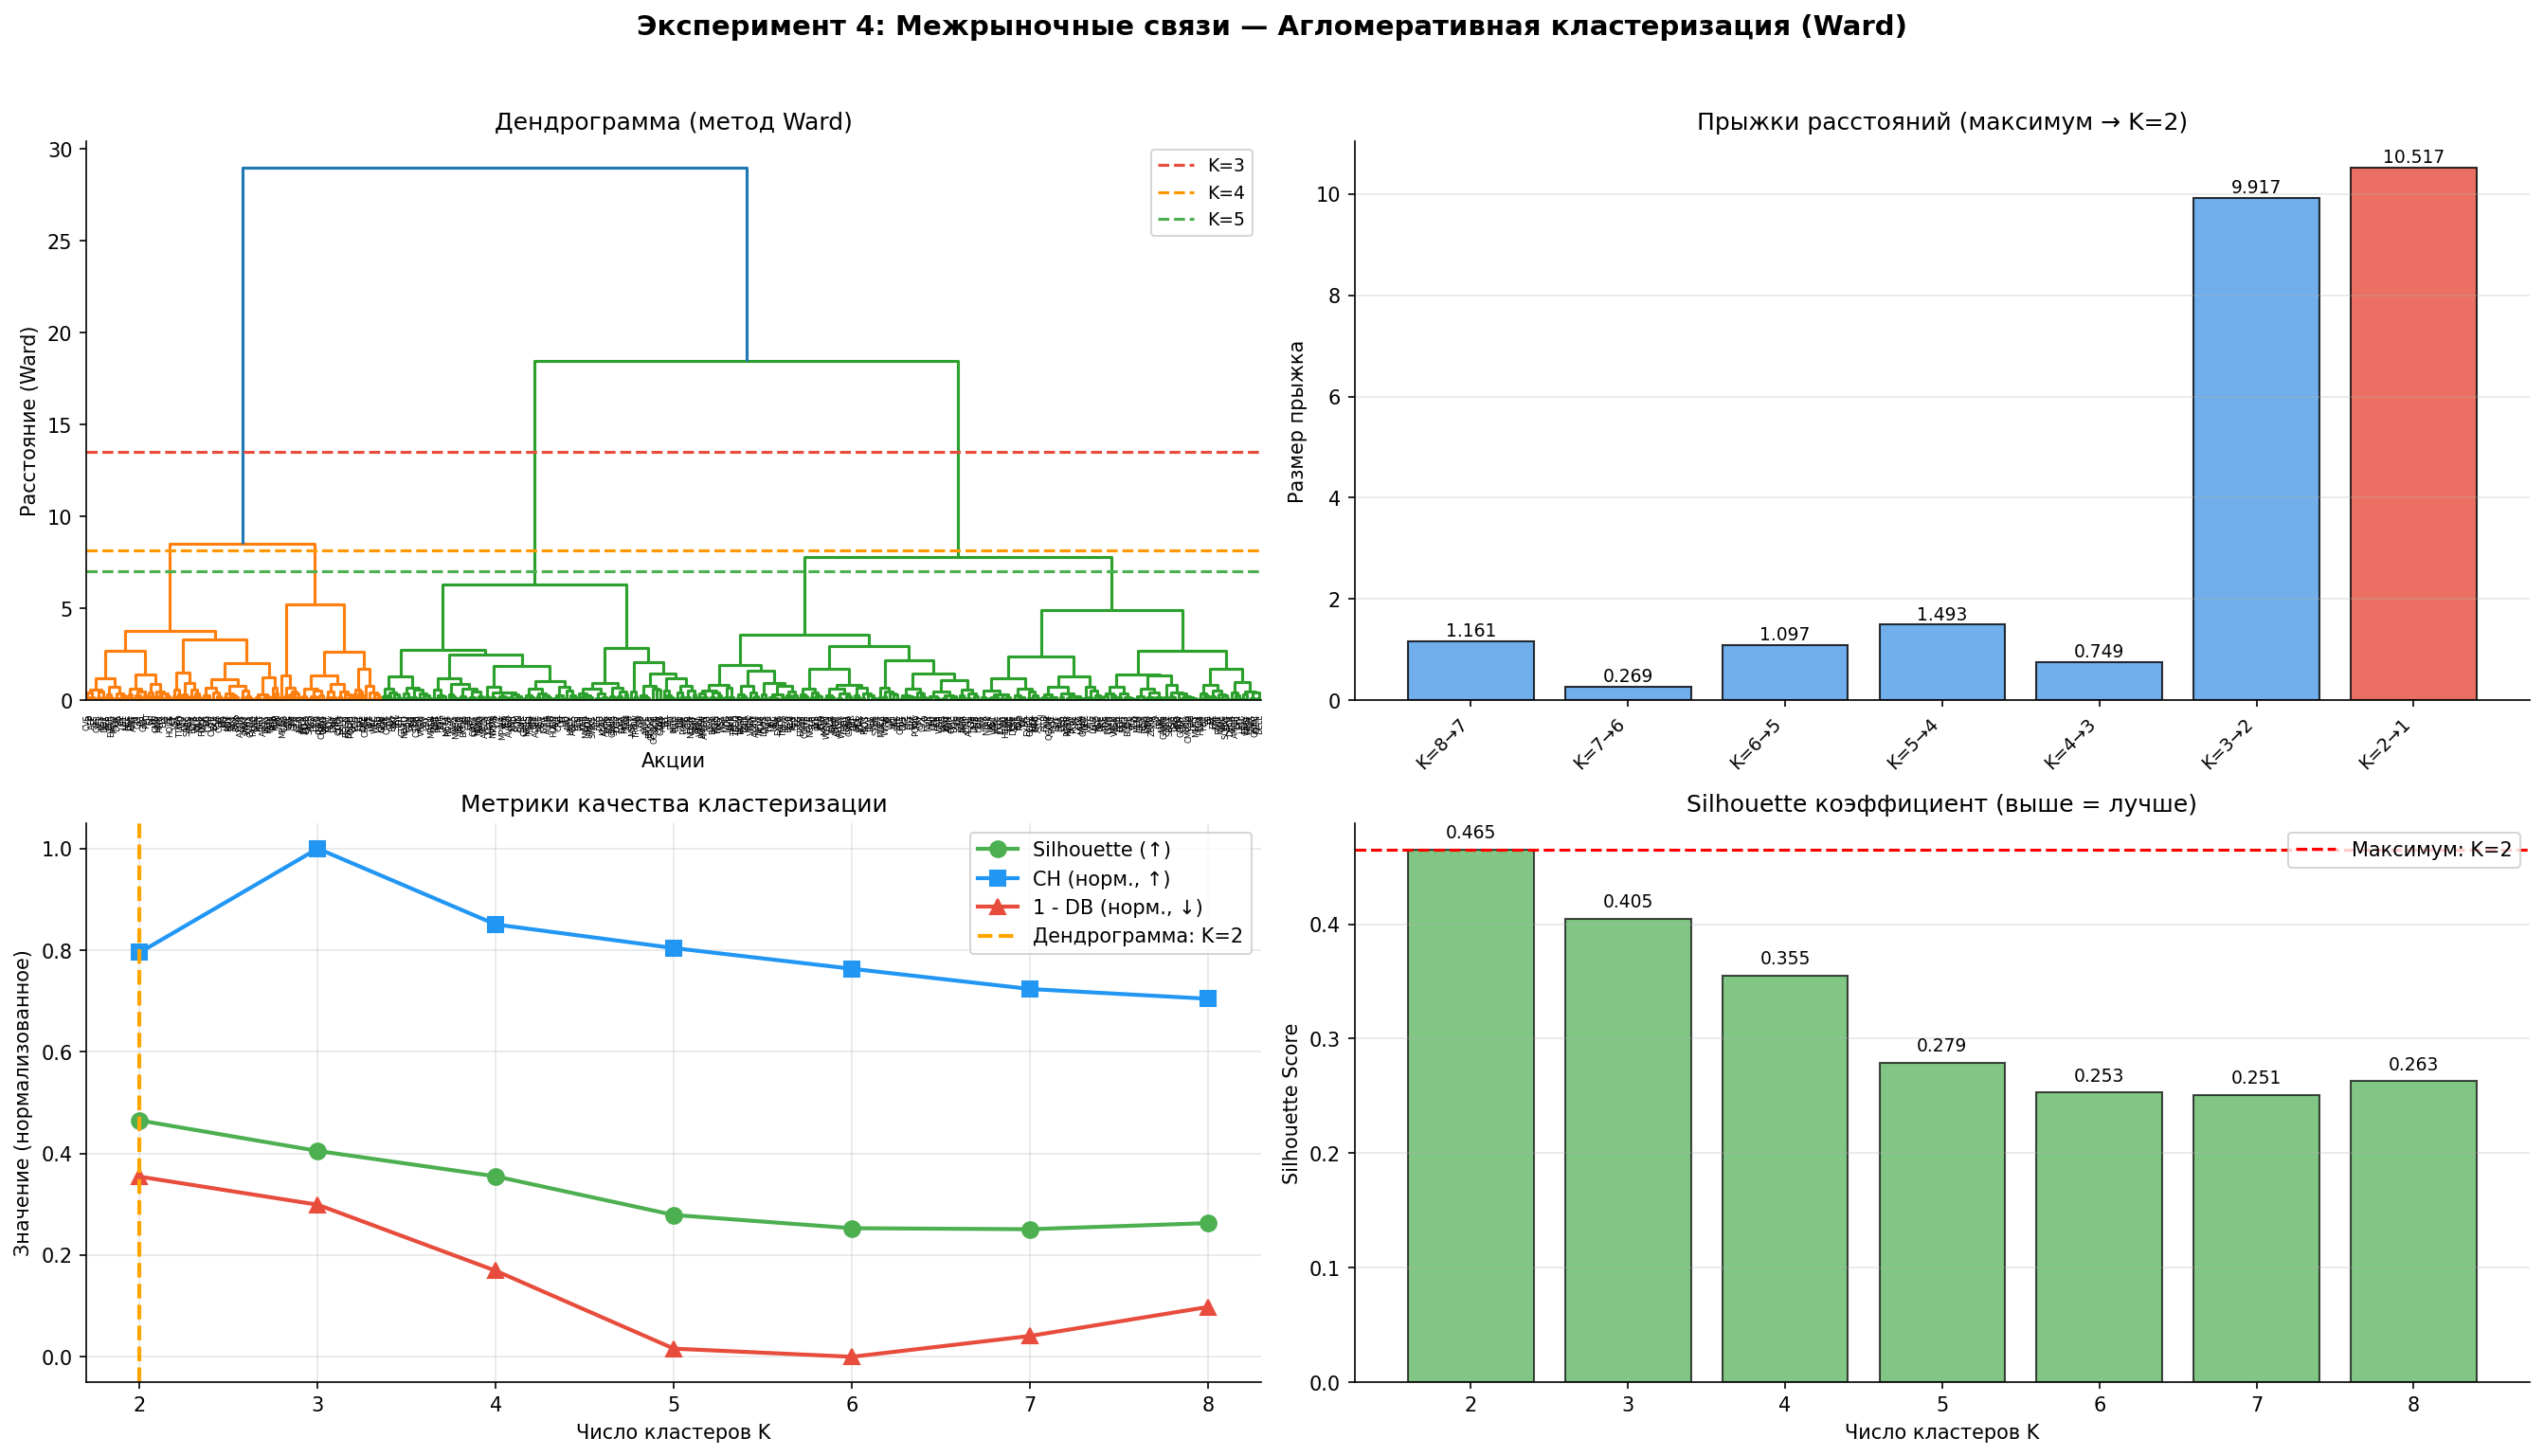


Сводная таблица для диплома

Таблица 1. Метрики качества агломеративной кластеризации
   Silhouette     CH     DB
K                          
2       0.465  521.9  0.725
3       0.405  656.1  0.787
4       0.355  558.1  0.933
5       0.279  527.6  1.105
6       0.253  500.9  1.123
7       0.251  474.8  1.077
8       0.263  462.2  1.013

Таблица 2. Интерпретация оптимальных K

┌────────────────────────────────────────────────────────────────────┐
│  Критерий              │ Оптимальный K │ Значение                 │
├────────────────────────────────────────────────────────────────────┤
│  Дендрограмма (прыжки) │      2       │ max gap = 10.517                  │
│  Silhouette            │      2       │ 0.465                      │
│  Calinski-Harabasz     │      3       │ 656.1                      │
│  Davies-Bouldin        │      2       │ 0.725                      │
└────────────────────────────────────────────────────────────────────┘


ИТОГОВЫЙ ВЕРДИКТ ПО АГЛОМЕРАТИВНОЙ КЛАСТЕРИЗ

In [4]:
# ── АГЛОМЕРАТИВНАЯ КЛАСТЕРИЗАЦИЯ: дендрограмма + анализ для K=2..8 ──────────────
from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("=" * 70)
print(f"{EXP_NAME} — Агломеративная кластеризация (Ward)")
print("=" * 70)

# Определяем доступные признаки для вывода профилей
available_features = []
feature_names = {}

if 'corr_sp500' in X_raw.columns:
    available_features.append('corr_sp500')
    feature_names['corr_sp500'] = 'corr_sp500 '
if 'corr_calm' in X_raw.columns:
    available_features.append('corr_calm')
    feature_names['corr_calm'] = 'corr_calm'

if 'tail_dependence' in X_raw.columns:
    available_features.append('tail_dependence')
    feature_names['tail_dependence'] = 'tail_dependence'



print(f"\nДоступные признаки для вывода профилей: {list(feature_names.values())}")

# Строим матрицу связей
Z = linkage(X_scaled, method='ward')

# ── 1. АНАЛИЗ ПРЫЖКОВ (дендрограмма) ─────────────────────────────────────────
N_LAST = 8
last_dists = Z[-N_LAST:, 2]
gaps = np.diff(last_dists)
dendro_k = N_LAST - int(np.argmax(gaps))

print("\nРасстояния последних слияний (дендрограмма):")
for i in range(len(gaps)):
    m = " ← МАКСИМУМ" if gaps[i] == gaps.max() else ""
    print(f"  K={N_LAST-i}→{N_LAST-i-1}: dist={last_dists[i]:.3f}, gap={gaps[i]:.3f}{m}")
print(f"\n→ Дендрограмма предлагает K={dendro_k}")

# ── 2. РАСЧЁТ МЕТРИК ДЛЯ K=2..8 ──────────────────────────────────────────────
print("\n" + "=" * 70)
print("Метрики качества для K=2..8 (агломеративная кластеризация)")
print("=" * 70)

K_RANGE = range(2, 9)
results = {'K': [], 'Silhouette': [], 'CH': [], 'DB': []}
all_labels_agg = {}

print(f"\n{'K':>4} {'Silhouette':>12} {'CH':>12} {'DB':>12}")
print("-" * 45)

for k in K_RANGE:
    # Получаем метки кластеров из дендрограммы
    labels = cut_tree(Z, n_clusters=k).flatten()
    all_labels_agg[k] = labels
    
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    
    results['K'].append(k)
    results['Silhouette'].append(round(sil, 3))
    results['CH'].append(round(ch, 1))
    results['DB'].append(round(db, 3))
    
    print(f"{k:>4} {sil:>12.3f} {ch:>12.1f} {db:>12.3f}")

# Таблица результатов
results_df = pd.DataFrame(results).set_index('K')
print("\n" + results_df.to_string())

# Оптимальные K по разным критериям
best_sil = results_df['Silhouette'].idxmax()
best_ch = results_df['CH'].idxmax()
best_db = results_df['DB'].idxmin()

print(f"\n📈 Оптимальные K по разным критериям:")
print(f"  • Дендрограмма (макс. прыжок):  K = {dendro_k}")
print(f"  • Silhouette (макс):           K = {best_sil}  (значение = {results_df.loc[best_sil, 'Silhouette']:.3f})")
print(f"  • Calinski-Harabasz (макс):    K = {best_ch}  (значение = {results_df.loc[best_ch, 'CH']:.1f})")
print(f"  • Davies-Bouldin (мин):        K = {best_db}  (значение = {results_df.loc[best_db, 'DB']:.3f})")

# ── 3. ПРОФИЛИ КЛАСТЕРОВ ДЛЯ КАЖДОГО K ────────────────────────────────────────
print("\n" + "=" * 70)
print("Профили кластеров для каждого K (агломеративная кластеризация)")
print("=" * 70)

for k in K_RANGE:
    labels = all_labels_agg[k]
    
    print(f"\n{'─'*50}")
    print(f"K = {k}")
    print(f"{'─'*50}")
    
    profile_data = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        n_stocks = mask.sum()
        
        if n_stocks == 0:
            continue
        
        row = {'Кластер': cluster_id, 'Акций': n_stocks}
        
        for feat in available_features:
            feat_mean = X_raw.loc[mask, feat].mean()
            row[feature_names[feat]] = round(feat_mean, 3)
        
        profile_data.append(row)
    
    if profile_data:
        profile_df = pd.DataFrame(profile_data)
        print(profile_df.to_string(index=False))
    else:
        print("  Нет данных для вывода профилей")

# ── 4. ВИЗУАЛИЗАЦИЯ: ДЕНДРОГРАММА + СТОЛБЧАТАЯ ДИАГРАММА ─────────────────────
fig = plt.figure(figsize=(18, 10))

# Дендрограмма (левая верхняя)
ax1 = plt.subplot(2, 2, 1)
dendrogram(Z, labels=X_scaled.index.tolist(),
           leaf_rotation=90, leaf_font_size=4,
           color_threshold=0.7 * max(Z[:, 2]), ax=ax1)
ax1.set_xlabel('Акции')
ax1.set_ylabel('Расстояние (Ward)')
ax1.set_title('Дендрограмма (метод Ward)')

# Линии для разных K
for k_cut, color in {3: '#e74c3c', 4: '#FF9800', 5: '#4CAF50'}.items():
    idx = -(k_cut - 1)
    thr = (Z[idx - 1, 2] + Z[idx, 2]) / 2
    ax1.axhline(thr, linestyle='--', linewidth=1.5, color=color, label=f'K={k_cut}')
ax1.legend(fontsize=9)

# Столбчатая диаграмма прыжков (правая верхняя)
ax2 = plt.subplot(2, 2, 2)
k_vals = list(range(N_LAST, N_LAST - len(gaps), -1))
colors = ['#e74c3c' if g == gaps.max() else '#4C9BE8' for g in gaps]
ax2.bar(range(len(gaps)), gaps, color=colors, alpha=0.8, edgecolor='black')
ax2.set_xticks(range(len(gaps)))
ax2.set_xticklabels([f'K={k}→{k-1}' for k in k_vals], rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Размер прыжка')
ax2.set_title(f'Прыжки расстояний (максимум → K={dendro_k})')
ax2.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, gap in enumerate(gaps):
    ax2.text(i, gap + 0.1, f'{gap:.3f}', ha='center', fontsize=9)

# График метрик качества (нижняя левая)
ax3 = plt.subplot(2, 2, 3)
ax3.plot(results_df.index, results_df['Silhouette'], 'o-', color='#4CAF50', linewidth=2, markersize=8, label='Silhouette (↑)')
ax3.plot(results_df.index, results_df['CH'] / results_df['CH'].max(), 's-', color='#2196F3', linewidth=2, markersize=8, label='CH (норм., ↑)')
ax3.plot(results_df.index, 1 - results_df['DB'] / results_df['DB'].max(), '^-', color='#e74c3c', linewidth=2, markersize=8, label='1 - DB (норм., ↓)')
ax3.axvline(dendro_k, color='orange', linestyle='--', linewidth=2, label=f'Дендрограмма: K={dendro_k}')
ax3.set_xlabel('Число кластеров K')
ax3.set_ylabel('Значение (нормализованное)')
ax3.set_title('Метрики качества кластеризации')
ax3.legend()
ax3.grid(alpha=0.3)

# График Silhouette (нижняя правая)
ax4 = plt.subplot(2, 2, 4)
ax4.bar(results_df.index, results_df['Silhouette'], color='#4CAF50', alpha=0.7, edgecolor='black')
ax4.axhline(results_df.loc[best_sil, 'Silhouette'], color='red', linestyle='--', linewidth=1.5, label=f'Максимум: K={best_sil}')
ax4.set_xlabel('Число кластеров K')
ax4.set_ylabel('Silhouette Score')
ax4.set_title('Silhouette коэффициент (выше = лучше)')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for k in results_df.index:
    val = results_df.loc[k, 'Silhouette']
    ax4.text(k, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)

plt.suptitle(f'{EXP_NAME} — Агломеративная кластеризация (Ward)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_dendrogram_full.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. ТАБЛИЦА ПО МЕТРИКАМ ДЛЯ ДИПЛОМА ─────────────────────────────────────────
print("\n" + "=" * 70)
print("Сводная таблица для диплома")
print("=" * 70)

print("\nТаблица 1. Метрики качества агломеративной кластеризации")
print(results_df.to_string())

print("\nТаблица 2. Интерпретация оптимальных K")
print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  Критерий              │ Оптимальный K │ Значение                 │
├────────────────────────────────────────────────────────────────────┤
│  Дендрограмма (прыжки) │      {dendro_k}       │ max gap = {max(gaps):.3f}                  │
│  Silhouette            │      {best_sil}       │ {results_df.loc[best_sil, 'Silhouette']:.3f}                      │
│  Calinski-Harabasz     │      {best_ch}       │ {results_df.loc[best_ch, 'CH']:.1f}                      │
│  Davies-Bouldin        │      {best_db}       │ {results_df.loc[best_db, 'DB']:.3f}                      │
└────────────────────────────────────────────────────────────────────┘
""")

# ── 6. ИТОГОВЫЙ ВЫВОД ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЕРДИКТ ПО АГЛОМЕРАТИВНОЙ КЛАСТЕРИЗАЦИИ")
print("=" * 70)

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  Агломеративная кластеризация (метод Ward)                        │
├────────────────────────────────────────────────────────────────────┤
│  • Дендрограмма предлагает:               K = {dendro_k}                       │
│  • Silhouette:                            K = {best_sil}                       │
│  • Calinski-Harabasz (CH):                K = {best_ch}                       │
│  • Davies-Bouldin (DB):                   K = {best_db}                       │
├────────────────────────────────────────────────────────────────────┤
│  Финальный выбор:                         K = {K_FINAL if 'K_FINAL' in dir() else 4}                    │
│    (на основе интерпретируемости профилей)                         │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n✓ График сохранён: {SAVE_PREFIX}_dendrogram_full.png")

## 5. Качественный анализ профилей K=3,4,5

### Как читать профили межрыночных связей
| Профиль | corr_sp500 | corr_calm | tail_dep | Тип |
|---|---|---|---|---|
| Высокая | Высокая | Высокая | Высокая | Рыночные — ходят с индексом |
| Низкая | Низкая | Низкая | Низкая | Независимые — диверсификаторы |
| Кризисная жертва | Средняя | Низкая | Высокая | Кажутся независимыми, но падают с рынком |


=======================================================  K=2


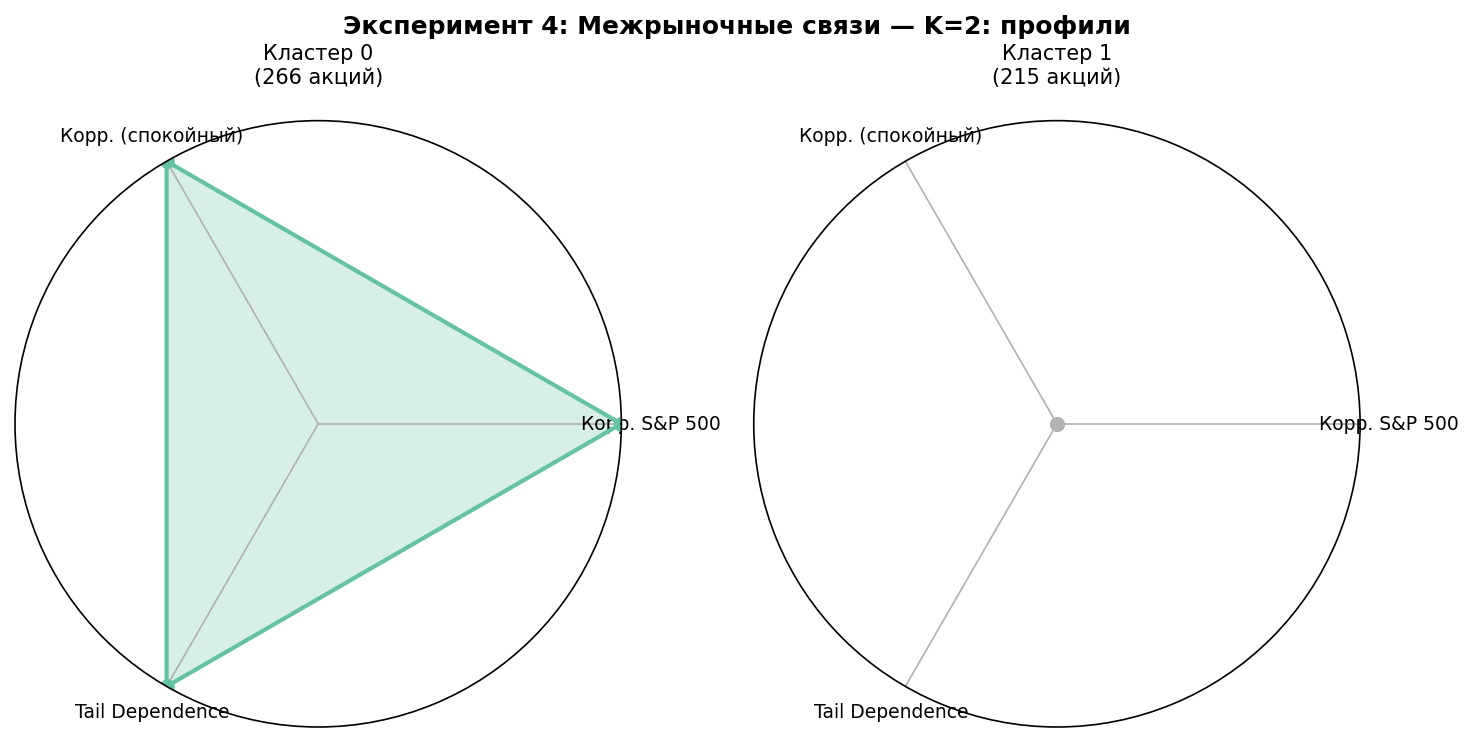


Средние значения (K=2):
           Корр. S&P 500  Корр. (спокойный)  Tail Dependence  Акций
Кластер 0          0.664              0.478            0.478    266
Кластер 1          0.497              0.278            0.334    215

Интерпретация:
  Кластер 0: Умеренно связанные (corr=0.664, calm=0.478, tail=0.478)
  Кластер 1: Слабо связанные (corr=0.497, calm=0.278, tail=0.334)

=======================================================  K=3


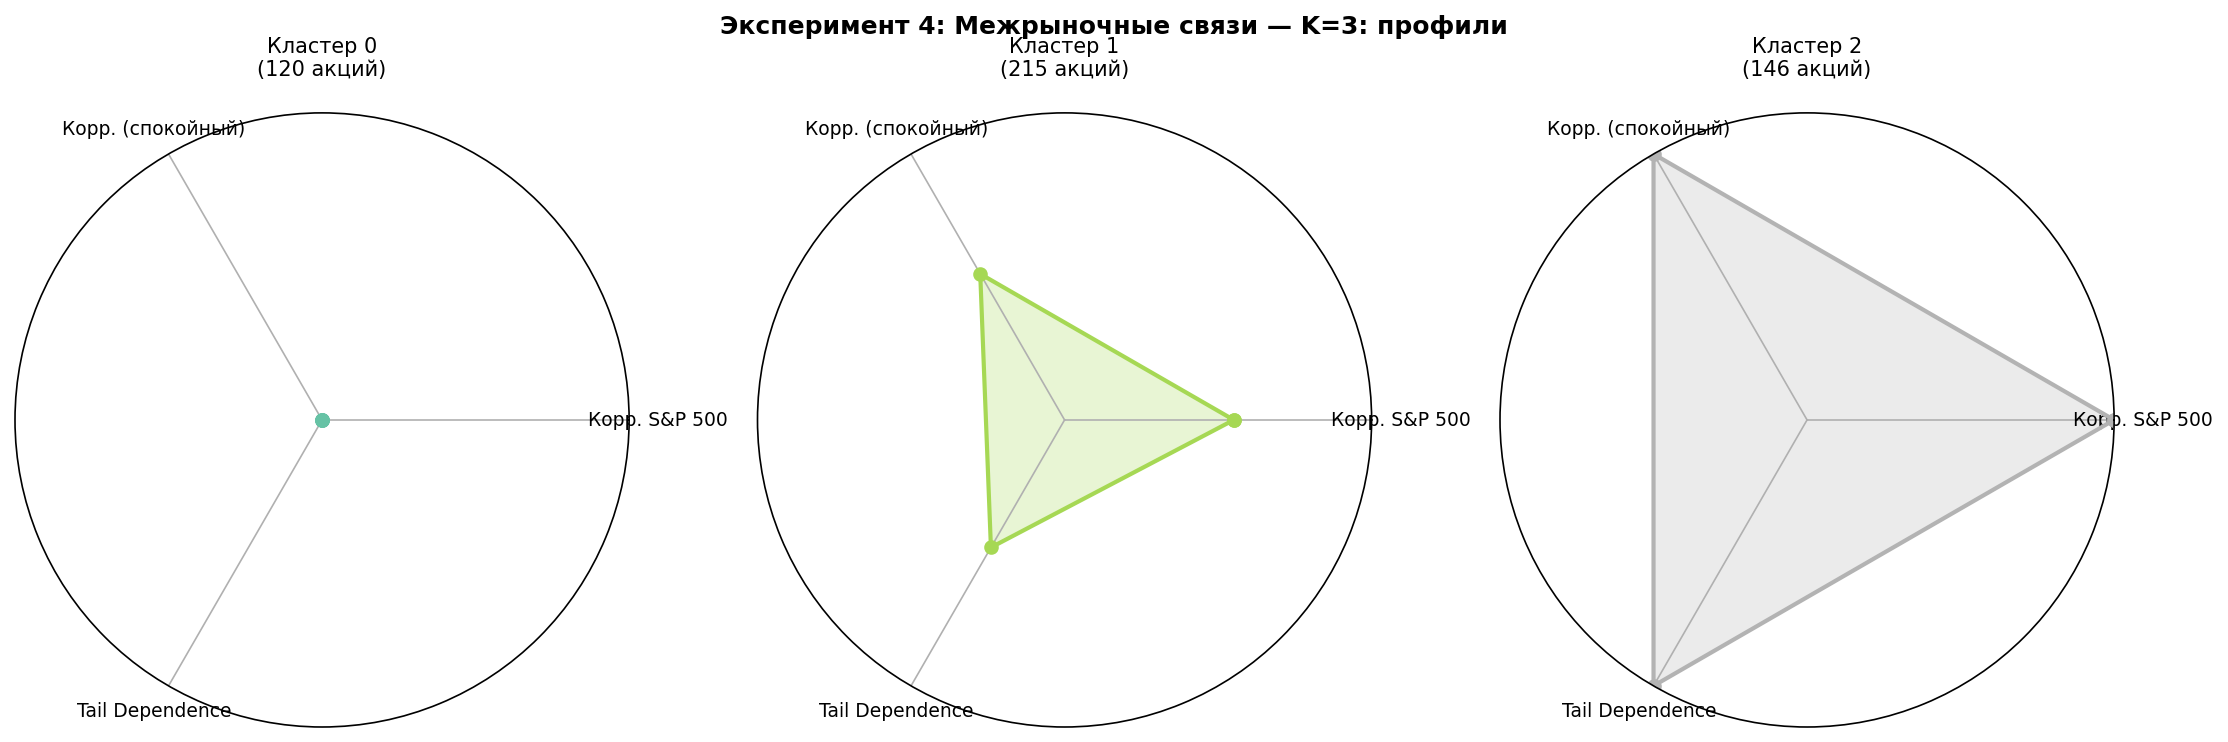


Средние значения (K=3):
           Корр. S&P 500  Корр. (спокойный)  Tail Dependence  Акций
Кластер 0          0.450              0.222            0.300    120
Кластер 1          0.589              0.388            0.405    215
Кластер 2          0.703              0.525            0.519    146

Интерпретация:
  Кластер 0: Независимые (диверсификаторы) (corr=0.450, calm=0.222, tail=0.300)
  Кластер 1: Умеренно связанные (corr=0.589, calm=0.388, tail=0.405)
  Кластер 2: Рыночные (высокая связь всегда) (corr=0.703, calm=0.525, tail=0.519)

=======================================================  K=4


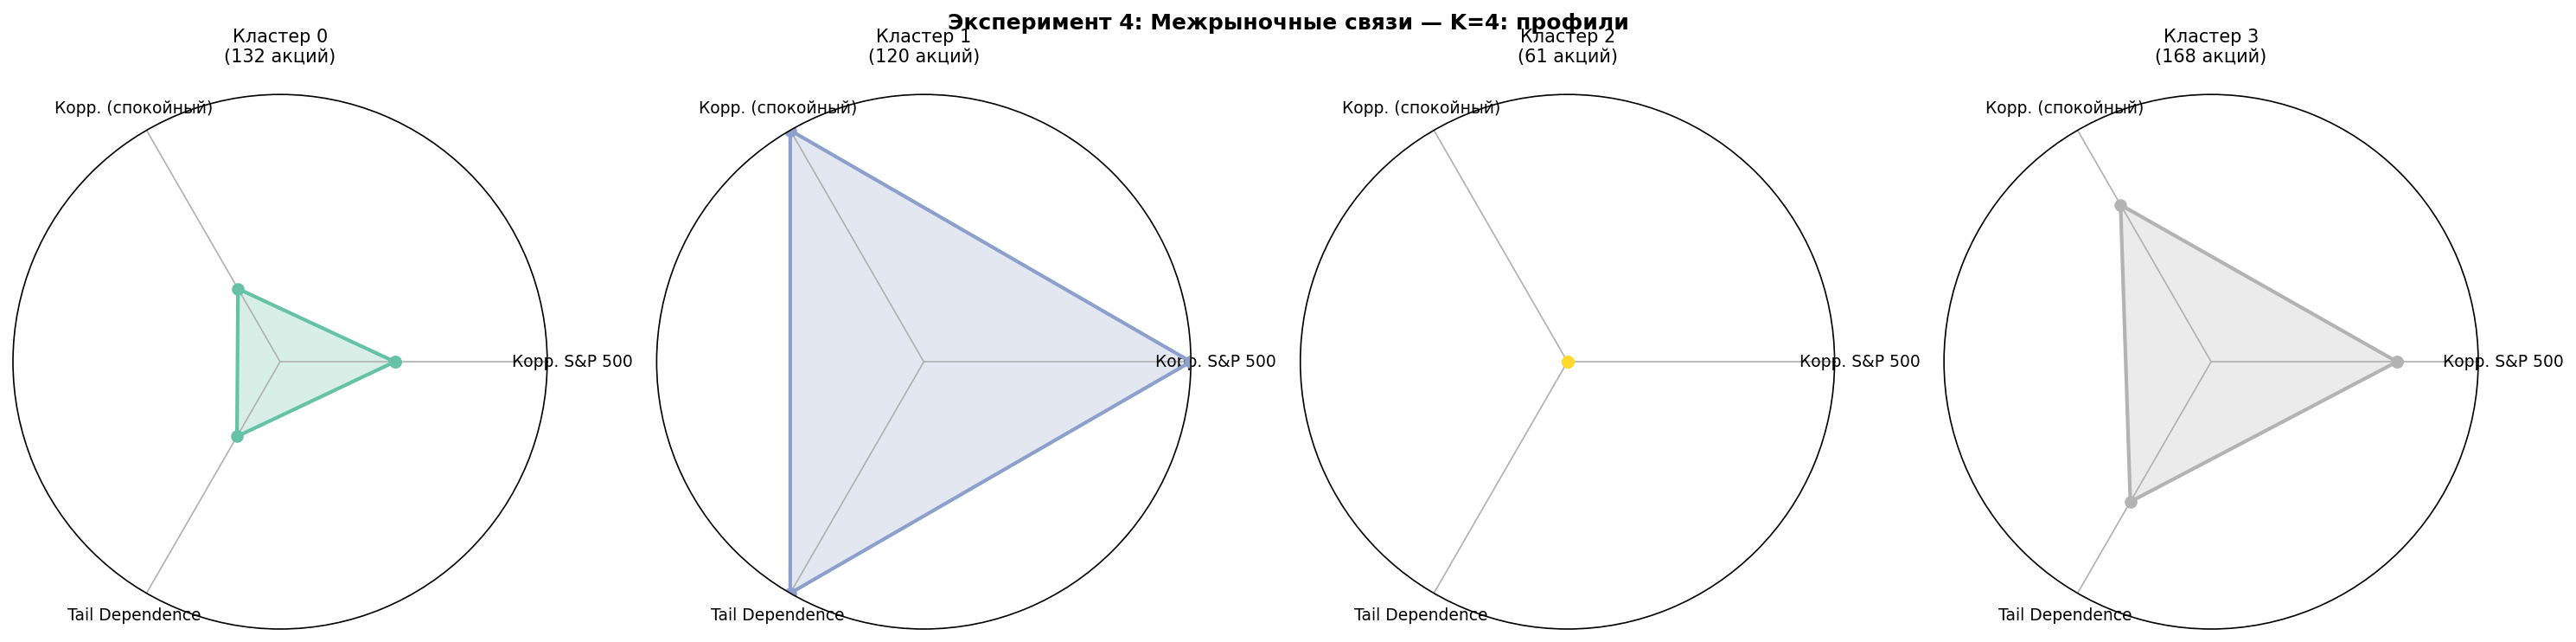


Средние значения (K=4):
           Корр. S&P 500  Корр. (спокойный)  Tail Dependence  Акций
Кластер 0          0.531              0.299            0.355    132
Кластер 1          0.713              0.536            0.530    120
Кластер 2          0.395              0.190            0.272     61
Кластер 3          0.616              0.425            0.428    168

Интерпретация:
  Кластер 0: Слабо связанные (corr=0.531, calm=0.299, tail=0.355)
  Кластер 1: Рыночные (высокая связь всегда) (corr=0.713, calm=0.536, tail=0.530)
  Кластер 2: Независимые (диверсификаторы) (corr=0.395, calm=0.190, tail=0.272)
  Кластер 3: Умеренно связанные (corr=0.616, calm=0.425, tail=0.428)

=======================================================  K=5


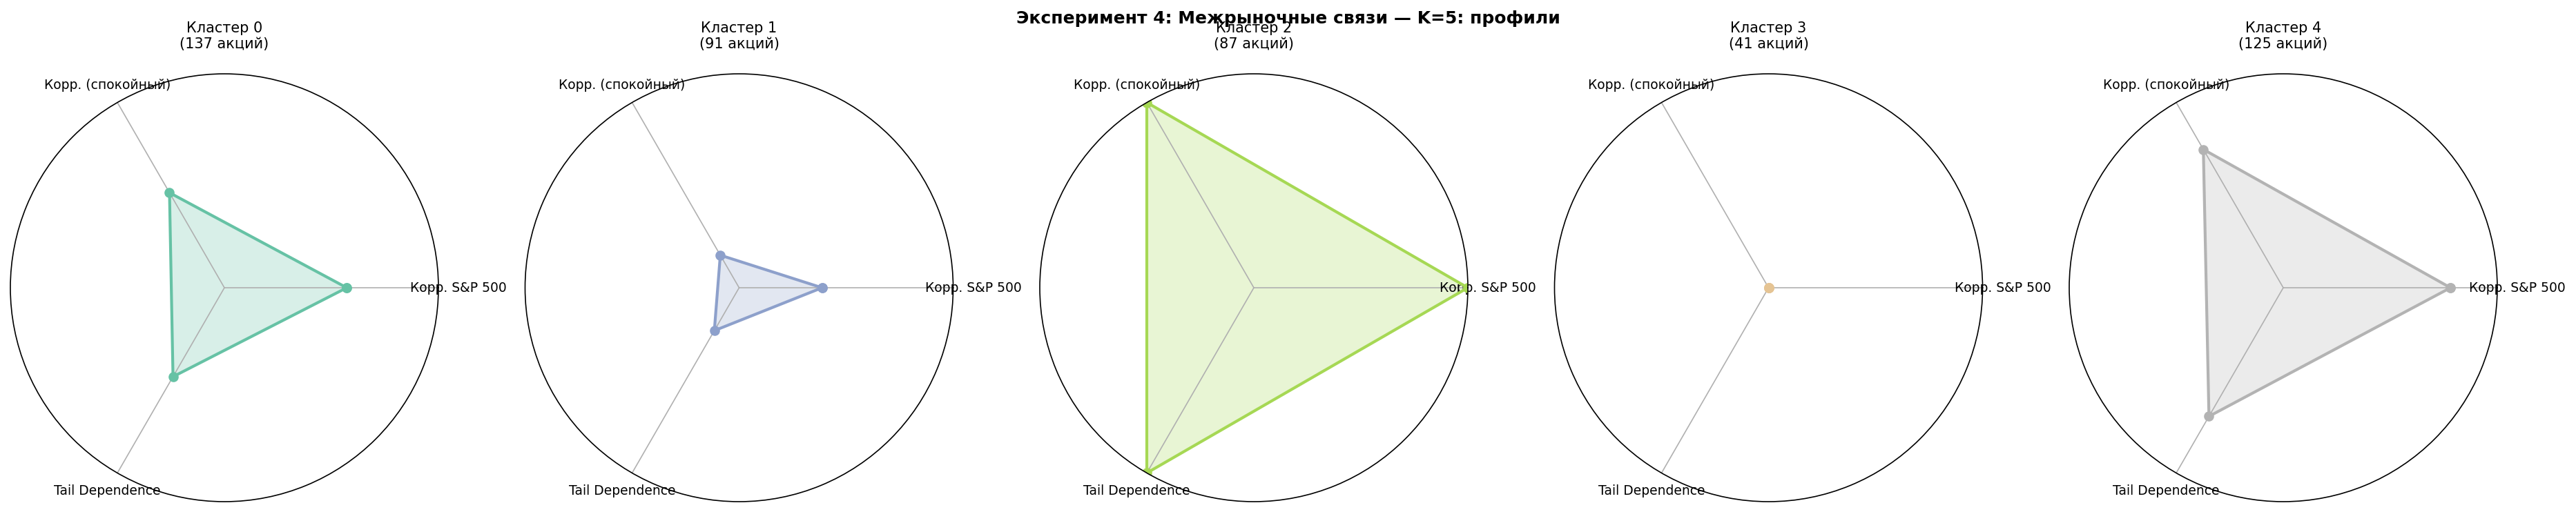


Средние значения (K=5):
           Корр. S&P 500  Корр. (спокойный)  Tail Dependence  Акций
Кластер 0          0.571              0.373            0.396    137
Кластер 1          0.504              0.249            0.324     91
Кластер 2          0.729              0.552            0.545     87
Кластер 3          0.361              0.184            0.258     41
Кластер 4          0.648              0.459            0.457    125

Интерпретация:
  Кластер 0: Умеренно связанные (corr=0.571, calm=0.373, tail=0.396)
  Кластер 1: Слабо связанные (corr=0.504, calm=0.249, tail=0.324)
  Кластер 2: Рыночные (высокая связь всегда) (corr=0.729, calm=0.552, tail=0.545)
  Кластер 3: Независимые (диверсификаторы) (corr=0.361, calm=0.184, tail=0.258)
  Кластер 4: Умеренно связанные (corr=0.648, calm=0.459, tail=0.457)


In [5]:
def plot_profiles(X_raw, labels, feature_labels, title, k, save_path=None):
    feats    = list(feature_labels.keys())
    f_lbls   = list(feature_labels.values())
    n_cl     = len(np.unique(labels))
    colors   = plt.cm.Set2(np.linspace(0, 1, n_cl))
    tmp      = X_raw[feats].copy()
    tmp['c'] = labels
    prof_raw = tmp.groupby('c')[feats].mean()
    prof_norm = pd.DataFrame(
        MinMaxScaler().fit_transform(prof_raw),
        columns=feats, index=prof_raw.index
    )
    angles = np.linspace(0, 2*np.pi, len(feats), endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(5*n_cl, 5))
    fig.suptitle(f'{title} — K={k}: профили',
                 fontsize=12, fontweight='bold')
    for i in range(n_cl):
        ax   = fig.add_subplot(1, n_cl, i+1, polar=True)
        vals = prof_norm.iloc[i].tolist() + [prof_norm.iloc[i].iloc[0]]
        ax.plot(angles, vals, 'o-', linewidth=2, color=colors[i])
        ax.fill(angles, vals, alpha=0.25, color=colors[i])
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(f_lbls, size=9)
        ax.set_ylim(0, 1)
        ax.set_yticks([])
        ax.set_title(f'Кластер {i}\n({(labels==i).sum()} акций)',
                     size=10, pad=18)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    out          = prof_raw.copy()
    out.columns  = [feature_labels[c] for c in feats]
    out.index    = [f'Кластер {i}' for i in out.index]
    out['Акций'] = [(labels==i).sum() for i in prof_raw.index]
    print(f"\nСредние значения (K={k}):")
    print(out.round(3).to_string())

    # Интерпретация
    print(f"\nИнтерпретация:")
    for i in range(n_cl):
        c  = prof_raw.iloc[i]['corr_sp500']
        cc = prof_raw.iloc[i]['corr_calm']
        td = prof_raw.iloc[i]['tail_dependence']

        if c > 0.65 and td > 0.5:
            interp = 'Рыночные (высокая связь всегда)'
        elif c < 0.45 and td < 0.35:
            interp = 'Независимые (диверсификаторы)'
        elif td > c + 0.15:
            interp = 'Кризисные жертвы (tail > corr — теряют независимость в панике)'
        elif c > 0.55:
            interp = 'Умеренно связанные'
        else:
            interp = 'Слабо связанные'
        print(f"  Кластер {i}: {interp} "
              f"(corr={c:.3f}, calm={cc:.3f}, tail={td:.3f})")
    return prof_raw


all_km_labels = {}
for k in [2, 3, 4, 5]:
    print(f"\n{'='*55}  K={k}")
    km  = KMeans(n_clusters=k, random_state=42, n_init=20)
    lbl = km.fit_predict(X_scaled)
    all_km_labels[k] = lbl
    plot_profiles(X_raw, lbl, LABELS, EXP_NAME, k,
                  f'{SAVE_PREFIX}_profiles_k{k}.png')

## 6. Финальный выбор K и именование

In [6]:
K_FINAL = 3  # ← обнови

CLUSTER_NAMES = {
    0: ('Независимые',       '#4CAF50'),  # corr=0.450, calm=0.222
    1: ('Умеренно связанные','#FF9800'),  # corr=0.589, calm=0.388
    2: ('Рыночные',          '#e74c3c'),  # corr=0.703, calm=0.525
}
# ВАЖНО: обнови под реальные профили!

km_final   = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
labels_km  = km_final.fit_predict(X_scaled)

agg_final  = AgglomerativeClustering(n_clusters=K_FINAL, linkage='ward')
labels_agg = agg_final.fit_predict(X_scaled)

X_result = X_raw.copy()
X_result['cluster_km']   = labels_km
X_result['cluster_agg']  = labels_agg
X_result['cluster_name'] = [CLUSTER_NAMES[c][0] for c in labels_km]
X_result['sector']       = df.loc[X_raw.index, 'sector']
X_result['name']         = df.loc[X_raw.index, 'name']

print(f"K={K_FINAL}")
for c, (name, _) in CLUSTER_NAMES.items():
    if c < K_FINAL:
        print(f"  {c}: {name} — {(labels_km==c).sum()} акций")

K=3
  0: Независимые — 120 акций
  1: Умеренно связанные — 215 акций
  2: Рыночные — 146 акций


## 7. GMM — вероятностная кластеризация

Эксперимент 4: Межрыночные связи — GMM анализ для K=2..8

Доступные признаки для вывода профилей: ['corr_sp500 ', 'corr_calm', 'tail_dependence']

   K   Silhouette           CH           DB          BIC          AIC
----------------------------------------------------------------------
   2        0.431        533.8        0.803       1980.6       1901.2
   3        0.398        639.9        0.809       2018.3       1897.2
   4        0.260        454.7        1.030       2052.6       1889.8
   5        0.277        464.4        0.960       2081.3       1876.6
   6        0.236        473.4        1.083       2129.4       1883.0
   7        0.244        462.3        1.103       2172.7       1884.5
   8        0.255        444.4        1.063       2222.6       1892.7

Таблица 1. Метрики качества GMM для K=2..8
   Silhouette     CH     DB     BIC     AIC
K                                          
2       0.431  533.8  0.803  1980.6  1901.2
3       0.398  639.9  0.809  2018.3  1897.2
4 

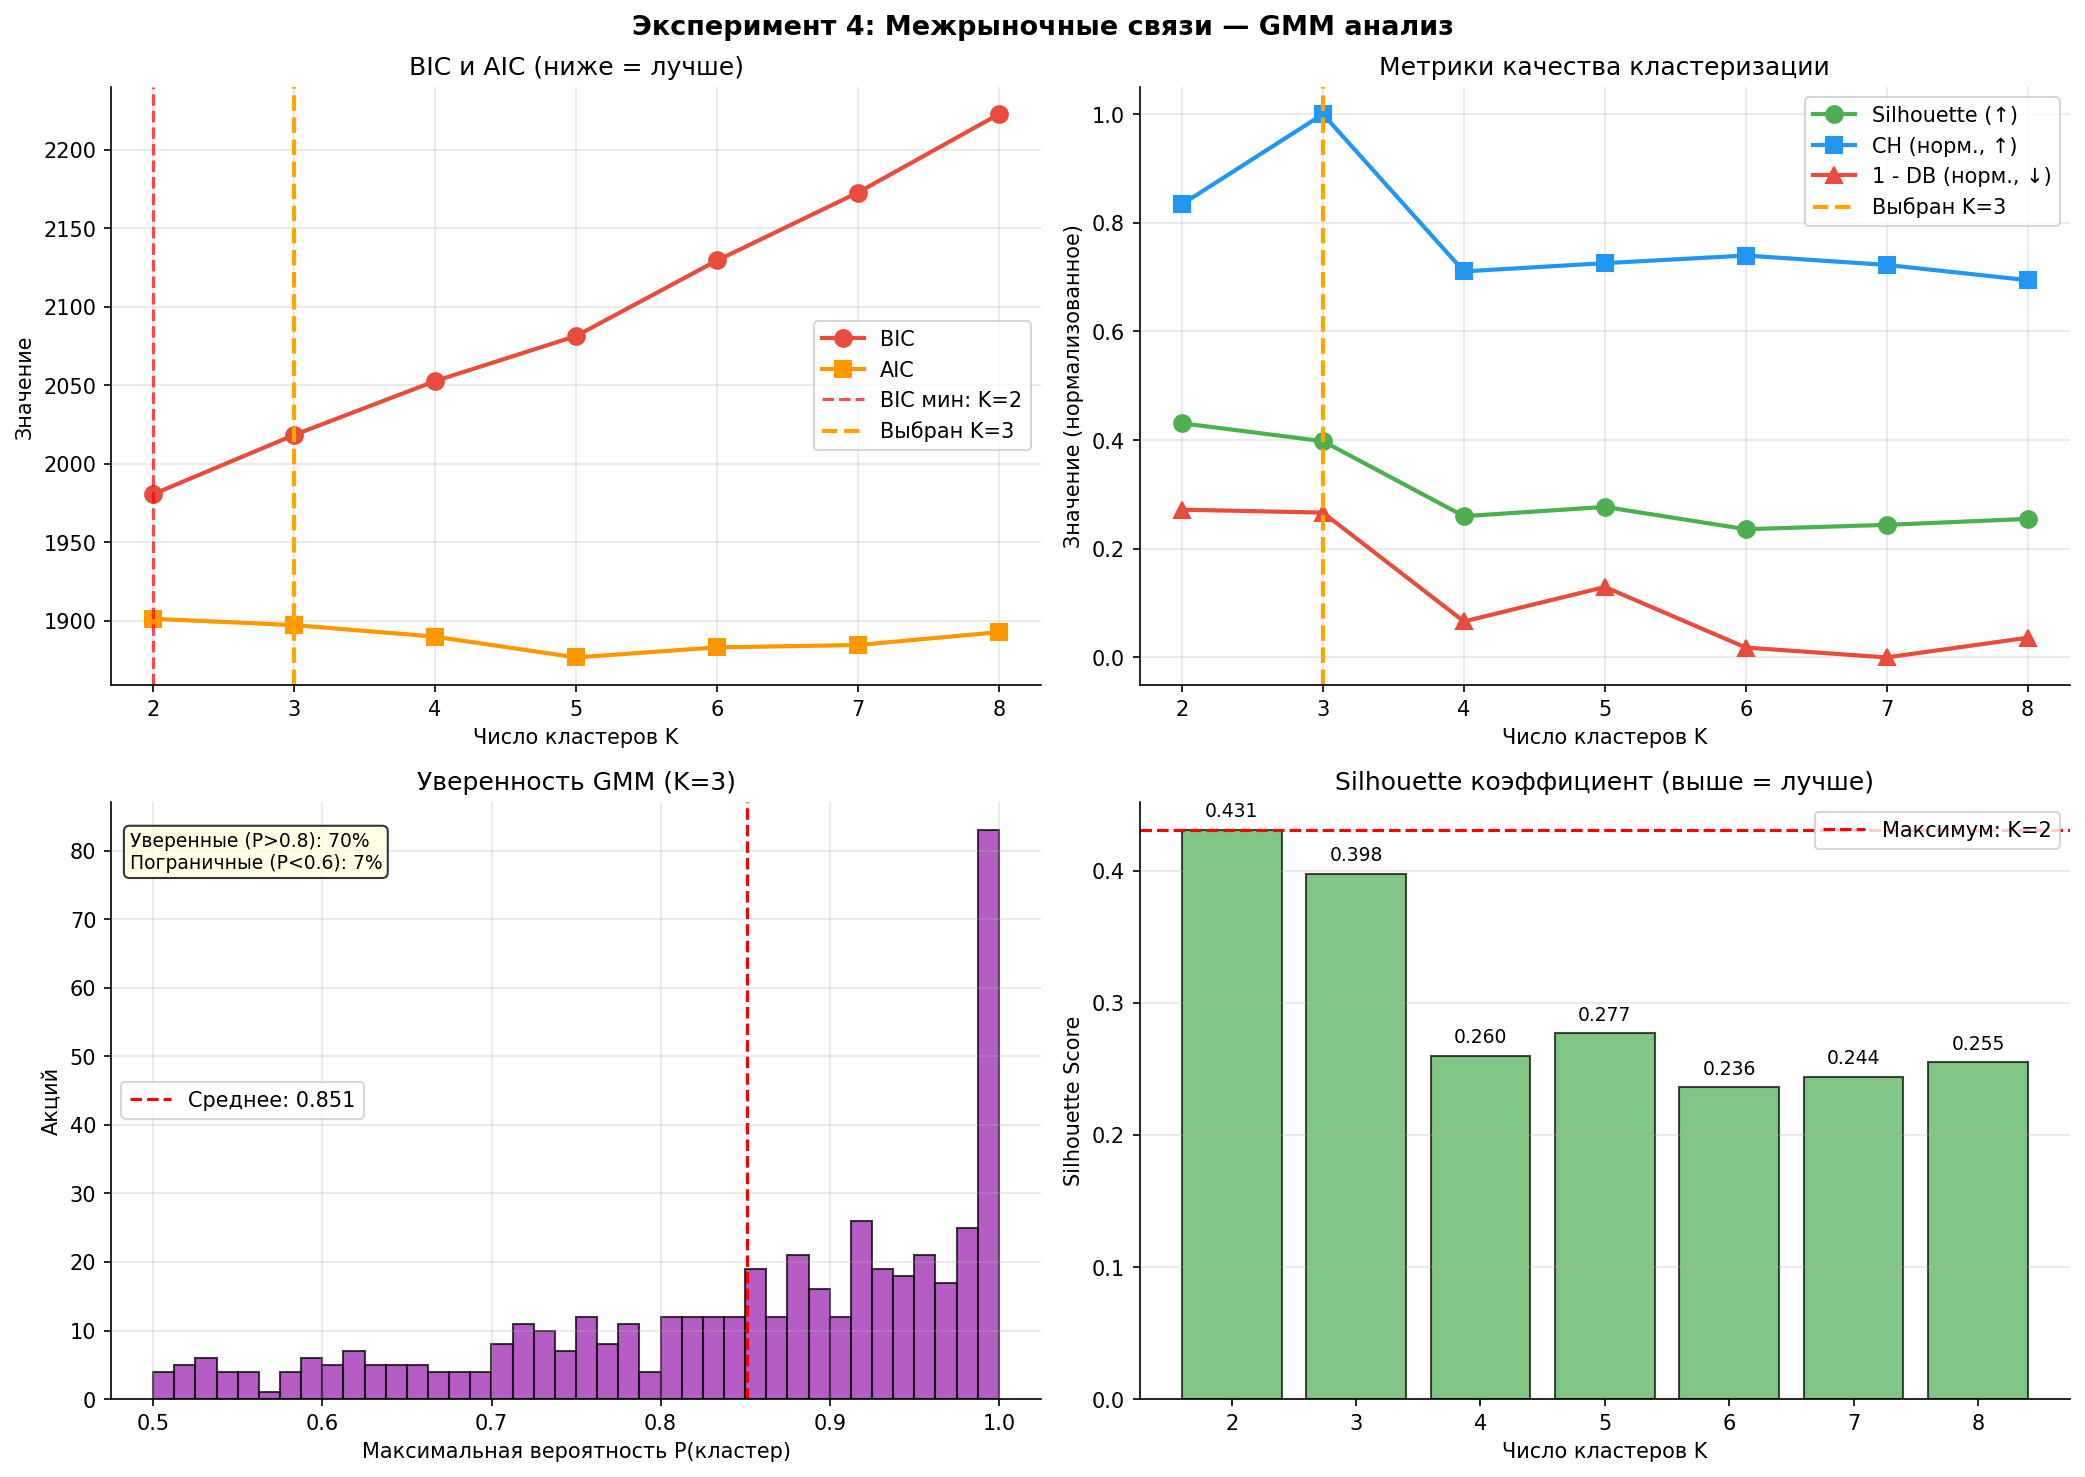


ИТОГОВЫЙ ВЕРДИКТ ПО GMM

┌────────────────────────────────────────────────────────────────────┐
│  GMM (Gaussian Mixture Model) анализ                              │
├────────────────────────────────────────────────────────────────────┤
│  • Silhouette (макс):                    K = 2                       │
│  • Calinski-Harabasz (макс):             K = 3                       │
│  • Davies-Bouldin (мин):                 K = 2                       │
│  • BIC (мин):                            K = 2                       │
│  • AIC (мин):                            K = 5                       │
├────────────────────────────────────────────────────────────────────┤
│  Финальный выбор:                         K = 3                         │
├────────────────────────────────────────────────────────────────────┤
│  Качество классификации:                                          │
│  • BIC = 2018.3                                    │
│  • Средняя уверенность = 0.851                      

In [7]:
# ── GMM АНАЛИЗ ДЛЯ K=2..8 (агломеративная логика) ──────────────────────────────
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("=" * 70)
print(f"{EXP_NAME} — GMM анализ для K=2..8")
print("=" * 70)

# Определяем доступные признаки для вывода профилей
available_features = []
feature_names = {}

if 'corr_sp500' in X_raw.columns:
    available_features.append('corr_sp500')
    feature_names['corr_sp500'] = 'corr_sp500 '
if 'corr_calm' in X_raw.columns:
    available_features.append('corr_calm')
    feature_names['corr_calm'] = 'corr_calm'

if 'tail_dependence' in X_raw.columns:
    available_features.append('tail_dependence')
    feature_names['tail_dependence'] = 'tail_dependence'


print(f"\nДоступные признаки для вывода профилей: {list(feature_names.values())}")

# ── 1. РАСЧЁТ GMM ДЛЯ K=2..8 ─────────────────────────────────────────────────
K_RANGE = range(2, 9)
results = {'K': [], 'Silhouette': [], 'CH': [], 'DB': [], 'BIC': [], 'AIC': []}
all_labels_gmm = {}
all_proba_gmm = {}
all_models_gmm = {}

print(f"\n{'K':>4} {'Silhouette':>12} {'CH':>12} {'DB':>12} {'BIC':>12} {'AIC':>12}")
print("-" * 70)

for k in K_RANGE:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type='full',
        random_state=42,
        n_init=10
    )
    gmm.fit(X_scaled)
    labels = gmm.predict(X_scaled)
    proba = gmm.predict_proba(X_scaled)
    
    all_labels_gmm[k] = labels
    all_proba_gmm[k] = proba
    all_models_gmm[k] = gmm
    
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    bic = gmm.bic(X_scaled)
    aic = gmm.aic(X_scaled)
    
    results['K'].append(k)
    results['Silhouette'].append(round(sil, 3))
    results['CH'].append(round(ch, 1))
    results['DB'].append(round(db, 3))
    results['BIC'].append(round(bic, 1))
    results['AIC'].append(round(aic, 1))
    
    print(f"{k:>4} {sil:>12.3f} {ch:>12.1f} {db:>12.3f} {bic:>12.1f} {aic:>12.1f}")

# Таблица результатов
results_df = pd.DataFrame(results).set_index('K')
print("\n" + "=" * 70)
print("Таблица 1. Метрики качества GMM для K=2..8")
print("=" * 70)
print(results_df.to_string())

# Оптимальные K по разным критериям
best_sil = results_df['Silhouette'].idxmax()
best_ch = results_df['CH'].idxmax()
best_db = results_df['DB'].idxmin()
best_bic = results_df['BIC'].idxmin()
best_aic = results_df['AIC'].idxmin()

print(f"\n📈 Оптимальные K по разным критериям (GMM):")
print(f"  • Silhouette (макс):           K = {best_sil}  (значение = {results_df.loc[best_sil, 'Silhouette']:.3f})")
print(f"  • Calinski-Harabasz (макс):    K = {best_ch}  (значение = {results_df.loc[best_ch, 'CH']:.1f})")
print(f"  • Davies-Bouldin (мин):        K = {best_db}  (значение = {results_df.loc[best_db, 'DB']:.3f})")
print(f"  • BIC (мин):                   K = {best_bic}  (значение = {results_df.loc[best_bic, 'BIC']:.0f})")
print(f"  • AIC (мин):                   K = {best_aic}  (значение = {results_df.loc[best_aic, 'AIC']:.0f})")

# ── 2. ПРОФИЛИ КЛАСТЕРОВ ДЛЯ КАЖДОГО K ────────────────────────────────────────
print("\n" + "=" * 70)
print("Профили кластеров для каждого K (GMM)")
print("=" * 70)

for k in K_RANGE:
    labels = all_labels_gmm[k]
    proba = all_proba_gmm[k]
    max_proba = proba.max(axis=1)
    
    print(f"\n{'─'*50}")
    print(f"K = {k}")
    print(f"{'─'*50}")
    
    profile_data = []
    for cluster_id in range(k):
        mask = labels == cluster_id
        n_stocks = mask.sum()
        
        if n_stocks == 0:
            continue
        
        row = {'Кластер': cluster_id, 'Акций': n_stocks, 'Уверенность': round(max_proba[mask].mean(), 3)}
        
        for feat in available_features:
            feat_mean = X_raw.loc[mask, feat].mean()
            row[feature_names[feat]] = round(feat_mean, 3)
        
        profile_data.append(row)
    
    if profile_data:
        profile_df = pd.DataFrame(profile_data)
        print(profile_df.to_string(index=False))
    else:
        print("  Нет данных для вывода профилей")
    
    # Дополнительная статистика по уверенности
    print(f"\n  Уверенность GMM: P>0.9: {(max_proba>0.9).mean()*100:.0f}%, P<0.6: {(max_proba<0.6).mean()*100:.0f}%")

# ── 3. ДЕТАЛЬНЫЙ АНАЛИЗ ДЛЯ K_FINAL ──────────────────────────────────────────
print("\n" + "=" * 70)
print(f"ДЕТАЛЬНЫЙ АНАЛИЗ GMM ДЛЯ K = {K_FINAL}")
print("=" * 70)

# Берём финальную модель
gmm_final = all_models_gmm[K_FINAL]
labels_gmm = all_labels_gmm[K_FINAL]
proba_gmm = all_proba_gmm[K_FINAL]
max_proba = proba_gmm.max(axis=1)

X_result['cluster_gmm'] = labels_gmm
X_result['gmm_max_prob'] = max_proba

print(f"\nGMM (K={K_FINAL}):")
for c in range(K_FINAL):
    mask = labels_gmm == c
    if mask.sum() > 0:
        print(f"  Кластер {c}: {mask.sum()} акций, средняя уверенность {max_proba[mask].mean():.3f}")

print(f"\n  P > 0.9 (уверенные):     {(max_proba>0.9).sum()} акций ({(max_proba>0.9).mean()*100:.0f}%)")
print(f"  P > 0.8:                 {(max_proba>0.8).sum()} акций ({(max_proba>0.8).mean()*100:.0f}%)")
print(f"  P < 0.6 (пограничные):   {(max_proba<0.6).sum()} акций ({(max_proba<0.6).mean()*100:.0f}%)")
print(f"  Средняя уверенность:     {max_proba.mean():.3f}")
print(f"  BIC = {gmm_final.bic(X_scaled):.1f}")
print(f"  AIC = {gmm_final.aic(X_scaled):.1f}")

# ── 4. ТОП-15 ПОГРАНИЧНЫХ АКЦИЙ ──────────────────────────────────────────────
print(f"\n📌 Топ-15 акций с наибольшей неопределённостью (пограничные):")
uncertainty = 1 - max_proba
uncertain_df = pd.DataFrame({
    'Акция': X_raw.index,
    'Кластер GMM': labels_gmm,
    'Max P(GMM)': max_proba.round(3),
    'Неопределённость': uncertainty.round(3)
}).sort_values('Неопределённость', ascending=False).head(15)
print(uncertain_df.to_string(index=False))

# ── 5. ВИЗУАЛИЗАЦИЯ ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{EXP_NAME} — GMM анализ', fontsize=13, fontweight='bold')

# График 1: BIC и AIC
ax = axes[0, 0]
ax.plot(results_df.index, results_df['BIC'], 'o-', color='#e74c3c', linewidth=2, markersize=8, label='BIC')
ax.plot(results_df.index, results_df['AIC'], 's-', color='#FF9800', linewidth=2, markersize=8, label='AIC')
ax.axvline(best_bic, color='red', linestyle='--', alpha=0.7, label=f'BIC мин: K={best_bic}')
ax.axvline(K_FINAL, color='orange', linestyle='--', linewidth=2, label=f'Выбран K={K_FINAL}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Значение')
ax.set_title('BIC и AIC (ниже = лучше)')
ax.legend()
ax.grid(alpha=0.3)

# График 2: Метрики качества
ax = axes[0, 1]
ax.plot(results_df.index, results_df['Silhouette'], 'o-', color='#4CAF50', linewidth=2, markersize=8, label='Silhouette (↑)')
ax.plot(results_df.index, results_df['CH'] / results_df['CH'].max(), 's-', color='#2196F3', linewidth=2, markersize=8, label='CH (норм., ↑)')
ax.plot(results_df.index, 1 - results_df['DB'] / results_df['DB'].max(), '^-', color='#e74c3c', linewidth=2, markersize=8, label='1 - DB (норм., ↓)')
ax.axvline(K_FINAL, color='orange', linestyle='--', linewidth=2, label=f'Выбран K={K_FINAL}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Значение (нормализованное)')
ax.set_title('Метрики качества кластеризации')
ax.legend()
ax.grid(alpha=0.3)

# График 3: Распределение уверенности GMM
ax = axes[1, 0]
ax.hist(max_proba, bins=40, color='#9C27B0', alpha=0.75, edgecolor='black')
ax.axvline(max_proba.mean(), color='red', linestyle='--', linewidth=1.5, label=f'Среднее: {max_proba.mean():.3f}')
ax.set_xlabel('Максимальная вероятность P(кластер)')
ax.set_ylabel('Акций')
ax.set_title(f'Уверенность GMM (K={K_FINAL})')
ax.legend()
ax.grid(alpha=0.3)

pct_confident = (max_proba > 0.8).mean() * 100
pct_uncertain = (max_proba < 0.6).mean() * 100
ax.text(0.02, 0.95, f'Уверенные (P>0.8): {pct_confident:.0f}%\nПограничные (P<0.6): {pct_uncertain:.0f}%',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# График 4: Сравнение Silhouette по K
ax = axes[1, 1]
ax.bar(results_df.index, results_df['Silhouette'], color='#4CAF50', alpha=0.7, edgecolor='black')
ax.axhline(results_df.loc[best_sil, 'Silhouette'], color='red', linestyle='--', linewidth=1.5, label=f'Максимум: K={best_sil}')
ax.set_xlabel('Число кластеров K')
ax.set_ylabel('Silhouette Score')
ax.set_title('Silhouette коэффициент (выше = лучше)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for k in results_df.index:
    val = results_df.loc[k, 'Silhouette']
    ax.text(k, val + 0.01, f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_gmm_full_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 6. ИТОГОВЫЙ ВЫВОД ─────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЕРДИКТ ПО GMM")
print("=" * 70)

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  GMM (Gaussian Mixture Model) анализ                              │
├────────────────────────────────────────────────────────────────────┤
│  • Silhouette (макс):                    K = {best_sil}                       │
│  • Calinski-Harabasz (макс):             K = {best_ch}                       │
│  • Davies-Bouldin (мин):                 K = {best_db}                       │
│  • BIC (мин):                            K = {best_bic}                       │
│  • AIC (мин):                            K = {best_aic}                       │
├────────────────────────────────────────────────────────────────────┤
│  Финальный выбор:                         K = {K_FINAL}                         │
├────────────────────────────────────────────────────────────────────┤
│  Качество классификации:                                          │
│  • BIC = {gmm_final.bic(X_scaled):.1f}                                    │
│  • Средняя уверенность = {max_proba.mean():.3f}                            │
│  • Уверенных (P>0.8): {pct_confident:.0f}% акций                           │
│  • Пограничных (P<0.6): {pct_uncertain:.0f}% акций                         │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n✓ График сохранён: {SAVE_PREFIX}_gmm_full_analysis.png")

## 8. DBSCAN — акции с нетипичным паттерном связи

In [8]:
k_nbrs       = 2 * len(FEATURES)
nbrs         = NearestNeighbors(n_neighbors=k_nbrs).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dists      = np.sort(distances[:, -1])[::-1]
x_v          = np.arange(len(k_dists))
p1, p2       = np.array([x_v[0], k_dists[0]]), np.array([x_v[-1], k_dists[-1]])
dlp          = np.abs(np.cross(p2-p1, p1-np.column_stack([x_v, k_dists])))
dlp         /= np.linalg.norm(p2-p1)
elbow_eps    = float(k_dists[np.argmax(dlp)])

EPS, MIN_SAMP = round(elbow_eps, 2), 5
labels_db     = DBSCAN(eps=EPS, min_samples=MIN_SAMP).fit_predict(X_scaled)
n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise       = int((labels_db == -1).sum())
noise_tickers = X_raw.index[labels_db == -1].tolist()

print(f"DBSCAN (eps={EPS}): {n_clusters_db} кластеров, {n_noise} выбросов")
if noise_tickers:
    print("\nАкции с нетипичным паттерном межрыночных связей:")
    nd = X_raw.loc[noise_tickers].copy()
    nd['sector'] = df.loc[noise_tickers, 'sector']
    nd_sorted = nd.sort_values('corr_sp500')
    print(nd_sorted.round(3).to_string())

    # Классифицируем выбросы
    print("\nИнтерпретация выбросов:")
    for ticker in noise_tickers:
        r = nd.loc[ticker]
        c  = r['corr_sp500']
        td = r['tail_dependence']
        cc = r['corr_calm']
        sec = r['sector']
        if c < 0.3 and td < 0.25:
            t = 'Истинный диверсификатор'
        elif td > c + 0.2:
            t = 'Корреляция взрывает в кризис'
        elif c < 0.2:
            t = 'Минимальная связь с рынком'
        else:
            t = 'Нетипичное сочетание метрик'
        print(f"  {ticker:6s} ({sec:25s}): {t}")

X_result['cluster_db'] = labels_db
valid_mask = labels_db != -1
sil_db = silhouette_score(
    X_scaled[valid_mask], labels_db[valid_mask]
) if n_clusters_db > 1 and valid_mask.sum() > n_clusters_db else np.nan

DBSCAN (eps=0.36): 1 кластеров, 26 выбросов

Акции с нетипичным паттерном межрыночных связей:
        corr_sp500  corr_calm  tail_dependence                  sector
ticker                                                                
MRNA         0.176      0.113            0.151             Health Care
KR           0.196      0.117            0.137        Consumer Staples
CLX          0.225      0.124            0.219        Consumer Staples
CPB          0.226      0.076            0.219        Consumer Staples
NEM          0.241      0.136            0.219               Materials
SJM          0.258      0.109            0.192        Consumer Staples
CAG          0.274      0.148            0.233        Consumer Staples
GIS          0.277      0.075            0.219        Consumer Staples
HRL          0.287      0.123            0.260        Consumer Staples
EQT          0.316      0.201            0.205                  Energy
DG           0.327      0.162            0.247        

## 9. Индекс неопределённости

Эксперимент 4: Межрыночные связи — Индекс неопределённости кластера (CUI)

Индекс неопределённости (K-Means vs Agglomerative vs GMM):
  • Ядро (все согласны):         438 акций (91%)
  • Пограничные (2/3 согласны):  43 акций (9%)
  • Конфликт (все разные):       0 акций (0%)


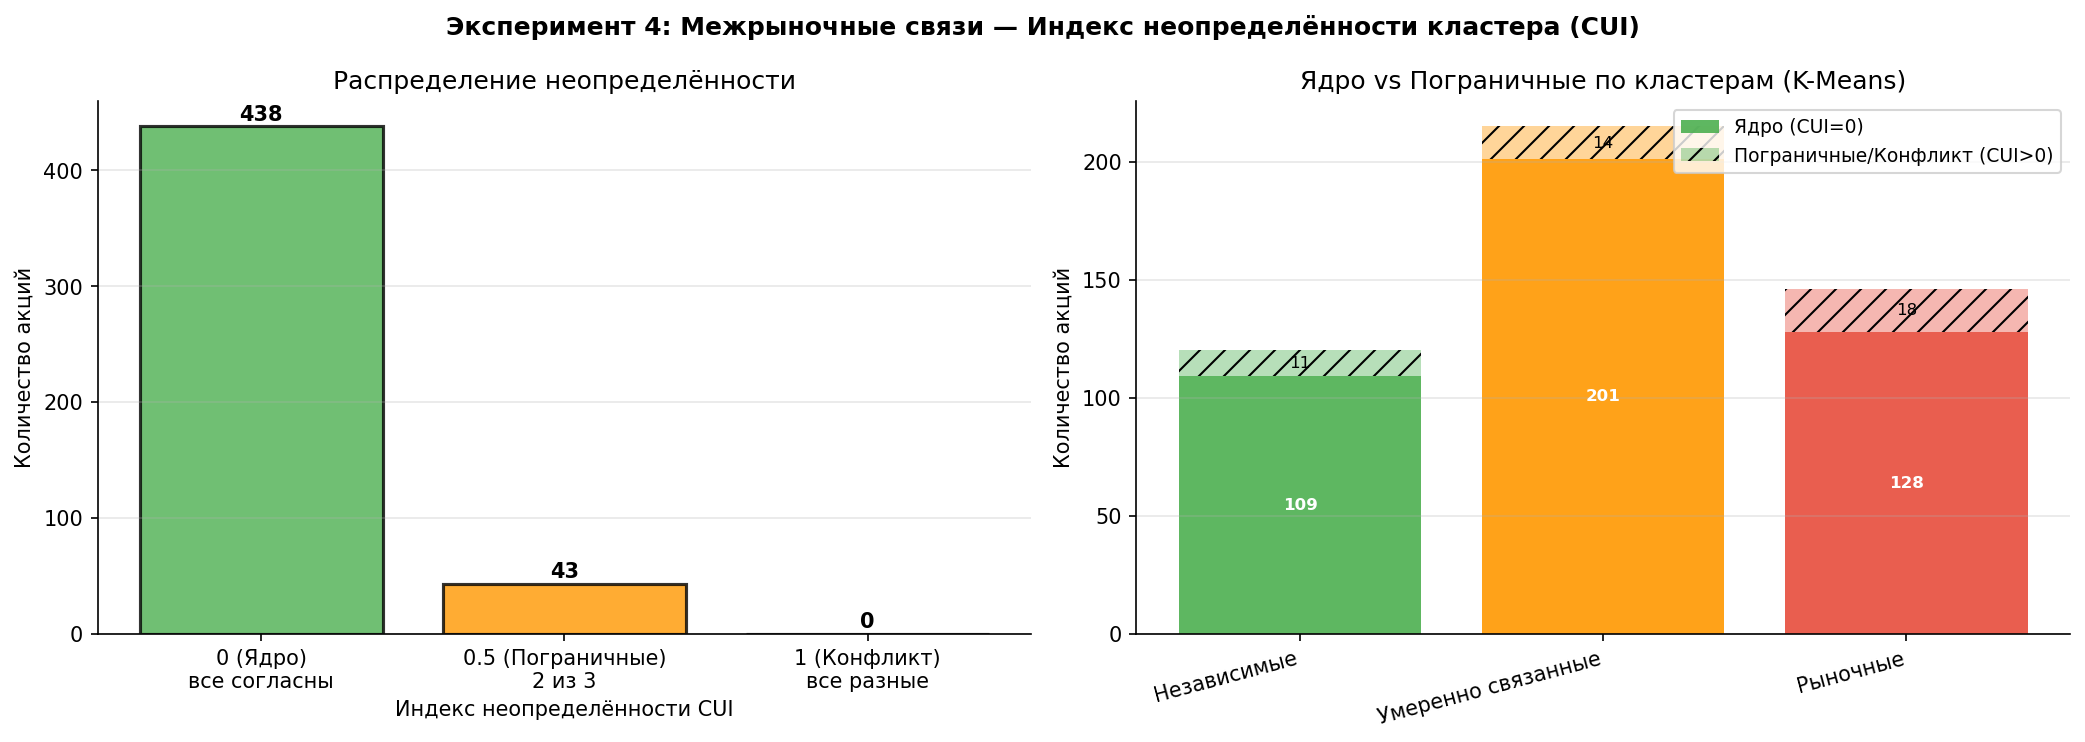


Акции с наибольшей неопределённостью (алгоритмы расходятся)
   Акция          KM кластер       Agglomerative                 GMM  CUI  corr_sp500   corr_calm  tail_dependence
0      A            Рыночные  Умеренно связанные            Рыночные  0.5        0.672      0.432            0.493
32  QCOM            Рыночные  Умеренно связанные            Рыночные  0.5        0.666      0.485            0.438
24   MOS         Независимые  Умеренно связанные  Умеренно связанные  0.5        0.474      0.374            0.315
25   MTD            Рыночные  Умеренно связанные            Рыночные  0.5        0.648      0.441            0.507
26   NRG         Независимые         Независимые  Умеренно связанные  0.5        0.537      0.322            0.247
27  PCAR            Рыночные  Умеренно связанные            Рыночные  0.5        0.642      0.485            0.452
28   PEG  Умеренно связанные  Умеренно связанные         Независимые  0.5        0.574      0.272            0.370
29   PEP  Умеренно 

In [9]:
# ── ИНДЕКС НЕОПРЕДЕЛЁННОСТИ (CUI) ПОЛНАЯ ВЕРСИЯ С ВИЗУАЛИЗАЦИЕЙ ──────────────────
from scipy.optimize import linear_sum_assignment

print("=" * 70)
print(f"{EXP_NAME} — Индекс неопределённости кластера (CUI)")
print("=" * 70)

# Функция выравнивания меток
def align_labels(ref, to_align, k):
    cost = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            cost[i, j] = -np.sum((ref == i) & (to_align == j))
    ri, ci = linear_sum_assignment(cost)
    m = dict(zip(ci, ri))
    return np.array([m.get(l, l) for l in to_align])

# Выравниваем метки
labels_agg_a = align_labels(labels_km, labels_agg, K_FINAL)
labels_gmm_a = align_labels(labels_km, labels_gmm, K_FINAL)

# Индекс неопределённости
stacked = np.column_stack([labels_km, labels_agg_a, labels_gmm_a])
n_uniq = np.array([len(np.unique(r)) for r in stacked])
uncert_idx = (n_uniq - 1) / (3 - 1)

X_result['uncertainty_idx'] = uncert_idx

# Статистика
n_core = (uncert_idx == 0.0).sum()
n_border = (uncert_idx == 0.5).sum()
n_conflict = (uncert_idx == 1.0).sum()

print(f"\nИндекс неопределённости (K-Means vs Agglomerative vs GMM):")
print(f"  • Ядро (все согласны):         {n_core} акций ({n_core/len(X_result)*100:.0f}%)")
print(f"  • Пограничные (2/3 согласны):  {n_border} акций ({n_border/len(X_result)*100:.0f}%)")
print(f"  • Конфликт (все разные):       {n_conflict} акций ({n_conflict/len(X_result)*100:.0f}%)")

# ── ВИЗУАЛИЗАЦИЯ ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'{EXP_NAME} — Индекс неопределённости кластера (CUI)',
             fontsize=12, fontweight='bold')

# График 1: Распределение неопределённости (столбцы)
ax = axes[0]

# Считаем количество для каждого значения
core_count = (uncert_idx == 0.0).sum()
border_count = (uncert_idx == 0.5).sum()
conflict_count = (uncert_idx == 1.0).sum()

# Рисуем три отдельных столбца
bars = ax.bar([0, 1, 2], [core_count, border_count, conflict_count],
              color=['#4CAF50', '#FF9800', '#e74c3c'],
              alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['0 (Ядро)\nвсе согласны', 
                    '0.5 (Пограничные)\n2 из 3', 
                    '1 (Конфликт)\nвсе разные'])
ax.set_xlabel('Индекс неопределённости CUI')
ax.set_ylabel('Количество акций')
ax.set_title('Распределение неопределённости')
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar, count in zip(bars, [core_count, border_count, conflict_count]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(count)), ha='center', fontsize=10, fontweight='bold')

# График 2: Ядро vs Пограничные по кластерам K-Means
ax = axes[1]

# Определяем цвета для кластеров
try:
    cluster_colors = {c: CLUSTER_NAMES[c][1] for c in range(K_FINAL)}
    cluster_names_dict = {c: CLUSTER_NAMES[c][0] for c in range(K_FINAL)}
except:
    cluster_colors = {0: '#4CAF50', 1: '#FF9800', 2: '#e74c3c', 3: '#2196F3'}
    cluster_names_dict = {0: 'Защитные', 1: 'Умеренно-агрессивные', 2: 'Агрессивные', 3: 'Рыночные'}

# Считаем ядро и границу по каждому кластеру
core_counts = []
border_counts = []
cluster_labels = []

for c_id in range(K_FINAL):
    mask = labels_km == c_id
    core_cnt = ((uncert_idx == 0) & mask).sum()
    border_cnt = ((uncert_idx > 0) & mask).sum()
    
    core_counts.append(core_cnt)
    border_counts.append(border_cnt)
    cluster_labels.append(cluster_names_dict.get(c_id, f'Кластер {c_id}'))

# Строим стековую столбчатую диаграмму
x_positions = np.arange(K_FINAL)
colors = [cluster_colors.get(i, '#999') for i in range(K_FINAL)]

bars_core = ax.bar(x_positions, core_counts, color=colors, 
                   alpha=0.9, label='Ядро (CUI=0)')
bars_border = ax.bar(x_positions, border_counts, bottom=core_counts,
                     color=colors, alpha=0.4, label='Пограничные/Конфликт (CUI>0)', hatch='//')

ax.set_xticks(x_positions)
ax.set_xticklabels(cluster_labels, rotation=15, ha='right')
ax.set_ylabel('Количество акций')
ax.set_title('Ядро vs Пограничные по кластерам (K-Means)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for i, (core, border) in enumerate(zip(core_counts, border_counts)):
    if core > 0:
        ax.text(i, core/2, str(int(core)), ha='center', va='center', 
                fontsize=8, color='white', fontweight='bold')
    if border > 0:
        ax.text(i, core + border/2, str(int(border)), ha='center', va='center', 
                fontsize=8, color='black')

plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_uncertainty.png', dpi=150, bbox_inches='tight')
plt.show()

# ── ТОП-15 АКЦИЙ С НАИБОЛЬШЕЙ НЕОПРЕДЕЛЁННОСТЬЮ ─────────────────────────────
print("\n" + "=" * 70)
print("Акции с наибольшей неопределённостью (алгоритмы расходятся)")
print("=" * 70)

# Получаем названия кластеров для каждого алгоритма
km_names = [cluster_names_dict.get(l, str(l)) for l in labels_km]
agg_names = [cluster_names_dict.get(l, str(l)) for l in labels_agg_a]
gmm_names = [cluster_names_dict.get(l, str(l)) for l in labels_gmm_a]

# Собираем данные для конфликтных акций (CUI > 0)
conflict_data = []
for i, (ticker, u_idx) in enumerate(zip(X_raw.index, uncert_idx)):
    if u_idx > 0:
        row = {
            'Акция': ticker,
            'KM кластер': km_names[i],
            'Agglomerative': agg_names[i],
            'GMM': gmm_names[i],
            'CUI': round(u_idx, 3)
        }
        # Добавляем доступные метрики
        for feat in available_features:
            if feat in X_raw.columns:
                row[feature_names.get(feat, feat)] = round(X_raw.loc[ticker, feat], 3)
        conflict_data.append(row)

if len(conflict_data) > 0:
    conflict_df = pd.DataFrame(conflict_data)
    display_cols = ['Акция', 'KM кластер', 'Agglomerative', 'GMM', 'CUI'] + \
                   [feature_names.get(f, f) for f in available_features if f in X_raw.columns]
    display_cols = [c for c in display_cols if c in conflict_df.columns]
    print(conflict_df[display_cols].sort_values('CUI', ascending=False).head(15).to_string())
else:
    print("  Нет акций с неопределённостью > 0")

# ── АКЦИИ С ПОЛНЫМ КОНСЕНСУСОМ (CUI=0) ─────────────────────────────────────────
print("\n" + "=" * 70)
print("Акции с полным консенсусом (CUI=0) — ядро кластеров")
print("=" * 70)

for c_id in range(K_FINAL):
    cluster_name = cluster_names_dict.get(c_id, f'Кластер {c_id}')
    mask = (labels_km == c_id) & (uncert_idx == 0)
    core_tickers = X_raw.index[mask].tolist()
    
    if len(core_tickers) > 0:
        print(f"\n{cluster_name} ({len(core_tickers)} акций):")
        print(f"  {', '.join(core_tickers[:5])}")
        if len(core_tickers) > 5:
            print(f"  ... и ещё {len(core_tickers) - 5} акций")

# ── ИТОГОВЫЙ ВЫВОД ─────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("ИТОГОВЫЙ ВЫВОД ПО ИНДЕКСУ НЕОПРЕДЕЛЁННОСТИ")
print("=" * 70)

print(f"""
┌────────────────────────────────────────────────────────────────────┐
│  CUI (Cluster Uncertainty Index)                                   │
├────────────────────────────────────────────────────────────────────┤
│  • Ядро (CUI=0):     {n_core:4d} акций ({n_core/len(X_result)*100:.0f}%) — все три алгоритма согласны          │
│  • Пограничные:      {n_border:4d} акций ({n_border/len(X_result)*100:.0f}%) — два из трёх согласны             │
│  • Конфликт:         {n_conflict:4d} акций ({n_conflict/len(X_result)*100:.0f}%) — все три разошлись            │
├────────────────────────────────────────────────────────────────────┤
│  Практический вывод:                                               │
│    • CUI=0 → высокая уверенность в классификации                  │
│    • CUI>0 → требуется дополнительный анализ                      │
│    • CUI=1 → полное расхождение алгоритмов                        │
└────────────────────────────────────────────────────────────────────┘
""")

print(f"\n✓ График сохранён: {SAVE_PREFIX}_uncertainty.png")

## 10. Анализ стабильности кластеров

In [10]:
simple_returns = pd.read_parquet('data/simple_returns.parquet')
sp500_ret      = pd.read_parquet('data/sp500_index.parquet')['sp500']

SUBPERIODS = {
    '2019–2020': ('2019-01-01', '2020-12-31'),
    '2021–2022': ('2021-01-01', '2022-12-31'),
    '2023–2024': ('2023-01-01', '2024-12-31'),
}


def compute_market_features(simple_ret, sp500, q=0.05):
    """Расчёт метрик межрыночных связей для подпериода."""
    mkt = sp500.reindex(simple_ret.index).dropna()
    s_a = simple_ret.reindex(mkt.index)
    a   = pd.concat([s_a, mkt], axis=1).dropna()
    if len(a) < 30:
        return [np.nan]*3

    corr_full = float(a.iloc[:,0].corr(a.iloc[:,1]))

    sp_vol    = sp500.rolling(21).std()
    vol_thr   = sp_vol.median()
    calm_days = sp_vol[sp_vol <= vol_thr].index
    calm_int  = a.index.intersection(calm_days)
    corr_c    = float(a.loc[calm_int,a.columns[0]].corr(
                      a.loc[calm_int,a.columns[1]])) \
                if len(calm_int) >= 20 else np.nan

    rv, mv  = a.iloc[:,0], a.iloc[:,1]
    r_thr   = rv.quantile(q)
    m_thr   = mv.quantile(q)
    m_low   = mv <= m_thr
    td      = float(((rv<=r_thr)&m_low).sum()/m_low.sum()) \
              if m_low.sum() > 0 else np.nan

    return [corr_full, corr_c, td]


subperiod_labels = {}
tickers_full     = X_raw.index.tolist()

for period_name, (start, end) in SUBPERIODS.items():
    print(f"Подпериод {period_name}...", end=' ')
    recs = []
    for ticker in tickers_full:
        try:
            s  = simple_returns[ticker].loc[start:end].dropna()
            sp = sp500_ret.loc[start:end]
            if len(s) < 100: continue
            feats = compute_market_features(s, sp)
            if not any(np.isnan(feats)):
                recs.append({'ticker': ticker,
                             **dict(zip(FEATURES, feats))})
        except Exception:
            pass

    sub_df  = pd.DataFrame(recs).set_index('ticker')
    sub_X   = pd.DataFrame(
        RobustScaler().fit_transform(sub_df[FEATURES]),
        index=sub_df.index, columns=FEATURES
    )
    sub_km  = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
    sub_lbl = sub_km.fit_predict(sub_X)
    subperiod_labels[period_name] = pd.Series(sub_lbl, index=sub_df.index)
    print(f"{len(sub_df)} акций")

common = sorted(set.intersection(*[
    set(v.index) for v in subperiod_labels.values()
]).intersection(set(tickers_full)))

stability_df = pd.DataFrame(
    {p: subperiod_labels[p].loc[common] for p in SUBPERIODS}
)
full_labels_c = pd.Series(labels_km, index=X_raw.index).loc[common]
for col in stability_df.columns:
    stability_df[col] = align_labels(
        full_labels_c.values, stability_df[col].values, K_FINAL
    )
stability_df['n_unique'] = stability_df[list(SUBPERIODS.keys())].nunique(axis=1)
stability_df['stable']   = stability_df['n_unique'] == 1
stability_df['full_km']  = full_labels_c.values

n_stable   = stability_df['stable'].sum()
pct_stable = n_stable / len(stability_df) * 100
print(f"\nСтабильность: {n_stable} акций ({pct_stable:.0f}%)")
print("Стабильность по кластерам:")
for c in range(K_FINAL):
    mask = stability_df['full_km'] == c
    if mask.sum() > 0:
        stab = stability_df.loc[mask,'stable'].mean()*100
        print(f"  {CLUSTER_NAMES[c][0]}: {stab:.0f}%")

Подпериод 2019–2020... 481 акций
Подпериод 2021–2022... 481 акций
Подпериод 2023–2024... 481 акций

Стабильность: 174 акций (36%)
Стабильность по кластерам:
  Независимые: 28%
  Умеренно связанные: 34%
  Рыночные: 46%


## 11. Силуэтный анализ и t-SNE

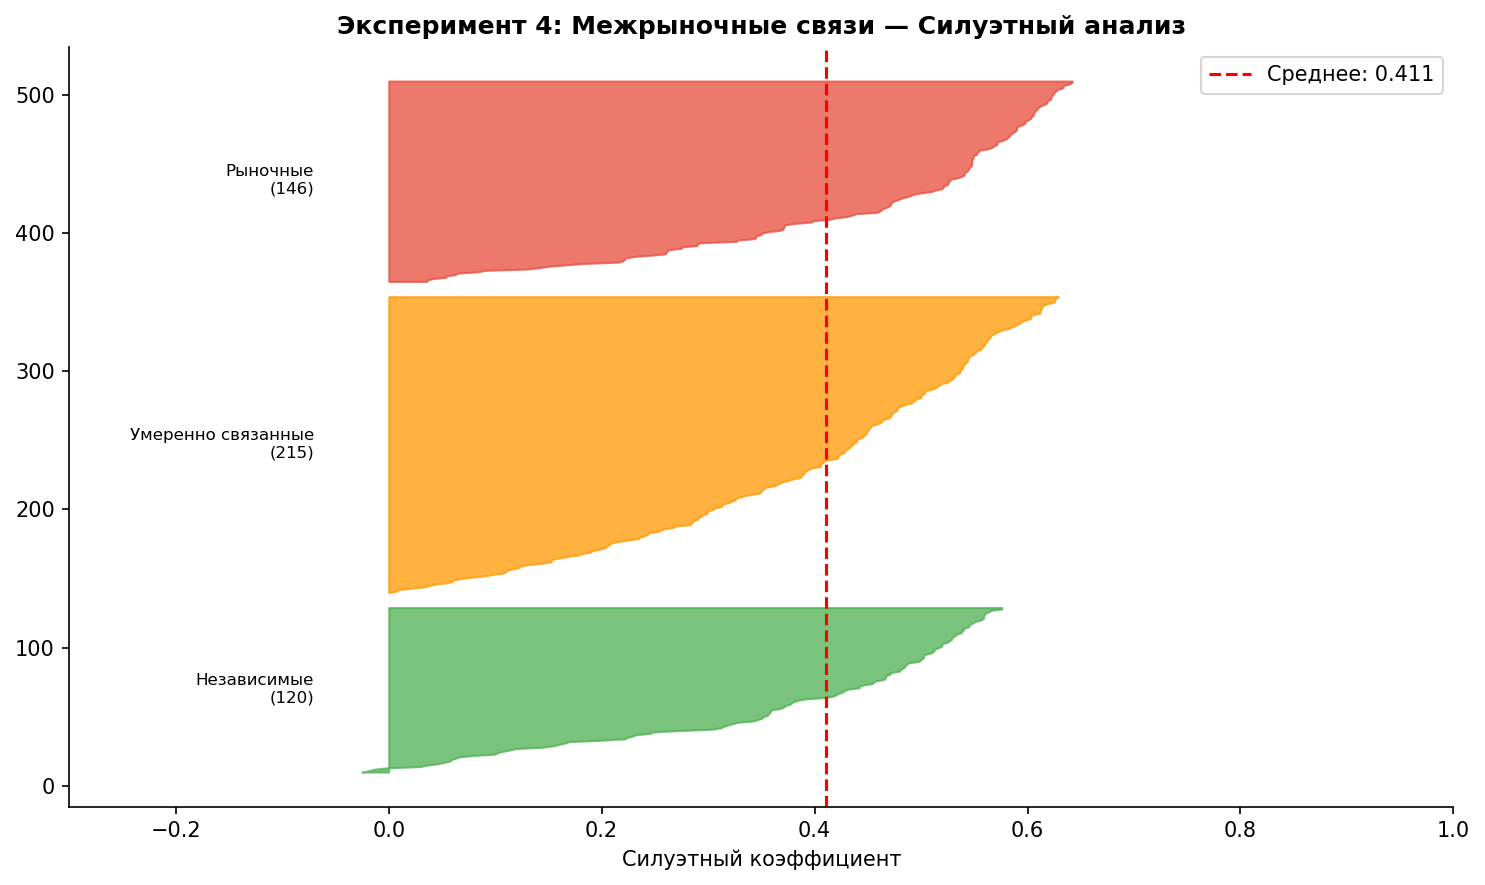

Silhouette: 0.411
Вычисляем t-SNE...


In [11]:
sil_samples = silhouette_samples(X_scaled, labels_km)
sil_avg     = silhouette_score(X_scaled, labels_km)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i in range(K_FINAL):
    cs      = np.sort(sil_samples[labels_km==i])
    y_upper = y_lower + len(cs)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cs,
                     alpha=0.75, color=CLUSTER_NAMES[i][1])
    ax.text(-0.07, y_lower+len(cs)/2,
            f'{CLUSTER_NAMES[i][0]}\n({len(cs)})',
            fontsize=8, ha='right', va='center')
    y_lower = y_upper + 10
ax.axvline(sil_avg, color='red', linestyle='--',
           label=f'Среднее: {sil_avg:.3f}')
ax.set_xlabel('Силуэтный коэффициент')
ax.set_title(f'{EXP_NAME} — Силуэтный анализ',
             fontsize=12, fontweight='bold')
ax.set_xlim(-0.3, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig(f'{SAVE_PREFIX}_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Silhouette: {sil_avg:.3f}")

print("Вычисляем t-SNE...")
coords = TSNE(n_components=2, perplexity=40, random_state=42,
              learning_rate='auto', max_iter=1500).fit_transform(X_scaled)

tsne_df = pd.DataFrame({
    'x': coords[:,0], 'y': coords[:,1],
    'ticker'         : X_raw.index,
    'cluster_name'   : [CLUSTER_NAMES[c][0] for c in labels_km],
    'sector'         : X_result['sector'].values,
    'corr_sp500'     : X_raw['corr_sp500'].round(3).values,
    'corr_calm'      : X_raw['corr_calm'].round(3).values,
    'tail_dependence': X_raw['tail_dependence'].round(3).values,
    'uncertainty'    : uncert_idx,
})
color_map = {CLUSTER_NAMES[c][0]: CLUSTER_NAMES[c][1]
             for c in range(K_FINAL)}
fig = px.scatter(
    tsne_df, x='x', y='y', color='cluster_name',
    color_discrete_map=color_map, hover_name='ticker',
    hover_data=['sector','corr_sp500','corr_calm',
                'tail_dependence','uncertainty'],
    title=f'{EXP_NAME} — t-SNE (K={K_FINAL})',
    width=900, height=620
)
fig.update_traces(marker=dict(size=7, opacity=0.8))
fig.update_layout(plot_bgcolor='#f8f9fa')
fig.write_html(f'{SAVE_PREFIX}_tsne.html')
fig.show()

## 12. Матрица ARI между всеми экспериментами

Матрица ARI между всеми экспериментами:
              Риск  Доходность  Сект. нез.  Межрыночные
Риск         1.000      -0.004       0.066        0.050
Доходность  -0.004       1.000       0.004        0.014
Сект. нез.   0.066       0.004       1.000        0.014
Межрыночные  0.050       0.014       0.014        1.000


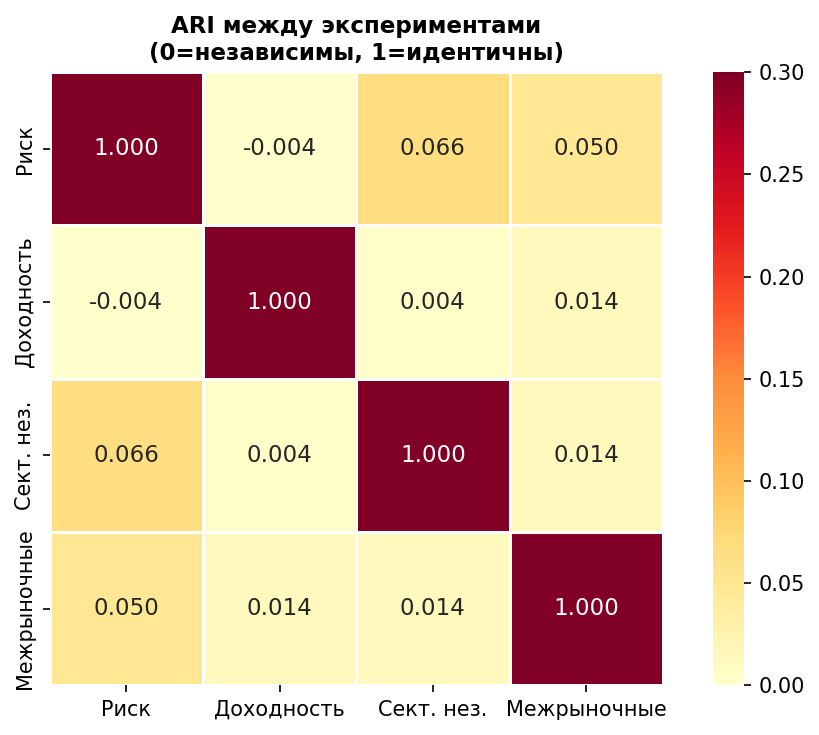


→ Низкий ARI = каждая группа метрик несёт уникальную информацию
  Это обосновывает необходимость всех четырёх экспериментов


In [12]:
from sklearn.preprocessing import LabelEncoder

all_idx = (X_raw.index
           .intersection(res_exp1.index)
           .intersection(res_exp2.index)
           .intersection(res_exp3.index))

exp4_labels = pd.Series(labels_km, index=X_raw.index).loc[all_idx]

le = LabelEncoder()
exp_data = {
    'Риск'        : le.fit_transform(res_exp1.loc[all_idx,'cluster_exp1_name'].fillna('?')),
    'Доходность'  : le.fit_transform(res_exp2.loc[all_idx,'cluster_exp2_name'].fillna('?')),
    'Сект. нез.'    : le.fit_transform(res_exp3.loc[all_idx,'cluster_exp3_name'].fillna('?')),
    'Межрыночные' : exp4_labels.values,
}

exp_names = list(exp_data.keys())
ari_matrix = pd.DataFrame(index=exp_names, columns=exp_names, dtype=float)

for i, n1 in enumerate(exp_names):
    for j, n2 in enumerate(exp_names):
        if i == j:
            ari_matrix.loc[n1, n2] = 1.0
        else:
            ari_matrix.loc[n1, n2] = round(
                adjusted_rand_score(exp_data[n1], exp_data[n2]), 3
            )

print("Матрица ARI между всеми экспериментами:")
print(ari_matrix.to_string())

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    ari_matrix.astype(float),
    annot=True, fmt='.3f',
    cmap='YlOrRd', vmin=0, vmax=0.3,
    linewidths=0.5, annot_kws={'size': 11},
    ax=ax, square=True
)
ax.set_title('ARI между экспериментами\n(0=независимы, 1=идентичны)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_ari_all_experiments.png', dpi=150, bbox_inches='tight')
plt.show()

ari_matrix.to_csv('data/ari_cross_experiments.csv')
print("\n→ Низкий ARI = каждая группа метрик несёт уникальную информацию")
print("  Это обосновывает необходимость всех четырёх экспериментов")

## 13. Полный вывод компаний по кластерам

In [13]:
print("=" * 70)
print(f"  ПОЛНЫЙ СОСТАВ КЛАСТЕРОВ — {EXP_NAME}")
print("=" * 70)

for c_id in range(K_FINAL):
    c_name, c_color = CLUSTER_NAMES[c_id]
    mask    = X_result['cluster_km'] == c_id
    members = X_result[mask].copy()\
              .sort_values('corr_sp500', ascending=False)

    print(f"\n{'─'*70}")
    print(f"  КЛАСТЕР {c_id}: {c_name.upper()} ({mask.sum()} акций)")
    print(f"  corr_sp500={members['corr_sp500'].mean():.3f} | "
          f"corr_calm={members['corr_calm'].mean():.3f} | "
          f"tail_dep={members['tail_dependence'].mean():.3f}")
    print(f"{'─'*70}")

    show = members[FEATURES + ['sector']].copy()
    show.index.name = 'Тикер'
    show.columns = [LABELS.get(c,c) for c in FEATURES] + ['Сектор']
    print(show.round(3).to_string())

    unc_mask = (X_result['cluster_km'] == c_id)
    core_pct = (uncert_idx[unc_mask.values] == 0).mean() * 100
    print(f"\n  Ядро кластера: {core_pct:.0f}%")

    st_mask = stability_df['full_km'] == c_id
    if st_mask.sum() > 0:
        stab_pct = stability_df.loc[st_mask,'stable'].mean()*100
        print(f"  Стабильность: {stab_pct:.0f}%")

  ПОЛНЫЙ СОСТАВ КЛАСТЕРОВ — Эксперимент 4: Межрыночные связи

──────────────────────────────────────────────────────────────────────
  КЛАСТЕР 0: НЕЗАВИСИМЫЕ (120 акций)
  corr_sp500=0.450 | corr_calm=0.222 | tail_dep=0.300
──────────────────────────────────────────────────────────────────────
       Корр. S&P 500  Корр. (спокойный)  Tail Dependence                  Сектор
Тикер                                                                           
DTE            0.588              0.196            0.342               Utilities
CNP            0.583              0.230            0.301               Utilities
AMT            0.564              0.213            0.329             Real Estate
EVRG           0.562              0.137            0.274               Utilities
NI             0.560              0.212            0.315               Utilities
CCI            0.559              0.228            0.342             Real Estate
EIX            0.554              0.216            0.356 

## 14. Итоговое сравнение алгоритмов

In [14]:
ari_km_agg  = adjusted_rand_score(labels_km, labels_agg)
ari_km_gmm  = adjusted_rand_score(labels_km, labels_gmm)
ari_agg_gmm = adjusted_rand_score(labels_agg, labels_gmm)

rows = []
for algo, lbl, extra in [
    ('K-Means',        labels_km,  f'K={K_FINAL}'),
    ('Агломеративная', labels_agg, f'K={K_FINAL}, Ward, dendro={dendro_k}'),
    ('GMM',            labels_gmm, f'K={K_FINAL}, BIC={gmm.bic(X_scaled):.0f}'),
]:
    rows.append({
        'Алгоритм'   : algo, 'Параметры': extra,
        'Silhouette↑': round(silhouette_score(X_scaled, lbl), 3),
        'CH↑'        : round(calinski_harabasz_score(X_scaled, lbl), 1),
        'DB↓'        : round(davies_bouldin_score(X_scaled, lbl), 3),
    })
rows.append({'Алгоритм': 'DBSCAN', 'Параметры': f'eps={EPS}',
             'Silhouette↑': round(sil_db,3) if not np.isnan(sil_db) else 'н/д',
             'CH↑': '—', 'DB↓': '—'})

print(f"{'='*65}")
print(f"  Сравнение алгоритмов — {EXP_NAME}")
print(f"{'='*65}")
print(pd.DataFrame(rows).set_index('Алгоритм').to_string())
print(f"  ARI (KM vs Aggl): {ari_km_agg:.3f}")
print(f"  ARI (KM vs GMM):  {ari_km_gmm:.3f}")
print(f"  ARI (Ag vs GMM):  {ari_agg_gmm:.3f}")
print(f"  DBSCAN выбросов:  {n_noise}")
print(f"  Ядро кластеров:   {n_core} ({n_core/len(X_result)*100:.0f}%)")
print(f"  Стабильность:     {pct_stable:.0f}%")
print(f"{'='*65}")

  Сравнение алгоритмов — Эксперимент 4: Межрыночные связи
                          Параметры Silhouette↑    CH↑    DB↓
Алгоритм                                                     
K-Means                         K=3       0.411  681.5  0.792
Агломеративная  K=3, Ward, dendro=2       0.405  656.1  0.787
GMM                   K=3, BIC=2223       0.398  639.9  0.809
DBSCAN                     eps=0.36         н/д      —      —
  ARI (KM vs Aggl): 0.823
  ARI (KM vs GMM):  0.814
  ARI (Ag vs GMM):  0.824
  DBSCAN выбросов:  26
  Ядро кластеров:   438 (91%)
  Стабильность:     36%


## 15. Сохранение

In [15]:
results = pd.DataFrame({
    'cluster_exp4_km'  : labels_km,
    'cluster_exp4_agg' : labels_agg,
    'cluster_exp4_gmm' : labels_gmm,
    'cluster_exp4_db'  : labels_db,
    'cluster_exp4_name': [CLUSTER_NAMES[c][0] for c in labels_km],
    'gmm_max_prob'     : max_proba,
    'uncertainty_idx'  : uncert_idx,
}, index=X_raw.index)
results.to_parquet('data/results_exp4.parquet')
stability_df.to_parquet('data/stability_exp4.parquet')

quality = {
    'experiment'     : 'Exp4_Market',
    'features'       : str(FEATURES),
    'k_final'        : K_FINAL,
    'silhouette_km'  : round(silhouette_score(X_scaled, labels_km), 3),
    'silhouette_agg' : round(silhouette_score(X_scaled, labels_agg), 3),
    'silhouette_gmm' : round(silhouette_score(X_scaled, labels_gmm), 3),
    'silhouette_db'  : round(sil_db,3) if not np.isnan(sil_db) else None,
    'ch_km'          : round(calinski_harabasz_score(X_scaled, labels_km),1),
    'db_score_km'    : round(davies_bouldin_score(X_scaled, labels_km),3),
    'ari_km_agg'     : round(ari_km_agg, 3),
    'ari_km_gmm'     : round(ari_km_gmm, 3),
    'ari_agg_gmm'    : round(ari_agg_gmm, 3),
    'gmm_bic'        : round(gmm.bic(X_scaled), 1),
    'dbscan_clusters': n_clusters_db,
    'dbscan_noise'   : n_noise,
    'dendro_k'       : dendro_k,
    'core_pct'       : round(n_core/len(X_result)*100, 1),
    'stability_pct'  : round(pct_stable, 1),
}
pd.DataFrame([quality]).to_csv('data/quality_exp4.csv', index=False)

print("✓ Сохранено:")
print("  data/results_exp4.parquet")
print("  data/stability_exp4.parquet")
print("  data/quality_exp4.csv")
print("  data/ari_cross_experiments.csv")
print(f"  Следующий шаг: notebook_07_comparison.ipynb")

✓ Сохранено:
  data/results_exp4.parquet
  data/stability_exp4.parquet
  data/quality_exp4.csv
  data/ari_cross_experiments.csv
  Следующий шаг: notebook_07_comparison.ipynb
